# PUC-Rio 
## Departamento de Engenharia Elétrica
## Trabalho 3 - Mapas de Kohonen

Estudante:

In [1]:
!git clone https://github.com/mdrs-thiago/minisom
import os 
os.chdir('minisom')

Cloning into 'minisom'...
remote: Enumerating objects: 1789, done.
remote: Counting objects: 100% (539/539), done.
remote: Compressing objects: 100% (75/75), done.
remote: Total 1789 (delta 498), reused 464 (delta 464), pack-reused 1250 (from 2)
Receiving objects: 100% (1789/1789), 15.66 MiB | 6.00 MiB/s, done.
Resolving deltas: 100% (995/995), done.


In [56]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
from sklearn.preprocessing import minmax_scale, StandardScaler

from minisom import MiniSom

In [3]:
dataset = pd.read_csv('https://raw.githubusercontent.com/mdrs-thiago/PUC_Redes_Neurais/main/datasets/c_thyroid.csv')

In [4]:
values = dataset.values[:,:-1]

## Parte 1 - Testando configurações

Nesta primeira etapa, iremos investigar como a configuração do mapa pode mudar de acordo com a escolha de parâmetros. 

In [5]:
print(values.shape)

(215, 5)


##### 1. Escolha os parâmetros para o primeiro teste usando SOM. Para cada parâmetro, justifique sua escolha. Avalie o resultado.

In [42]:
#decay function 


def decay_fcn(lr,actual_t,max_t):
    '''
    Função para decaimento da taxa de aprendizado. 
    
    ## INPUTS:
    lr - Taxa de aprendizado inicial
    actual_t - Tempo atual da iteração
    max_t - Tempo máximo da iteração

    ## OUTPUT:
    - taxa de aprendizado atualizada.
    '''

    new_lr = lr/(1 + 2*actual_t/max_t)

    return new_lr


m = int(np.sqrt(5*np.sqrt(values.shape[0]))) #Dimensão X do mapa de Kohonen
n = m #Dimensão Y do mapa de Kohonen
print("Dimensões do mapa de Kohonen: ", m, "x", n, ": ", m*n, "neurônios")
lr_ordering = 0.1 #Taxa de aprendizado - Ordering phase #! Alto > 0.02
lr_finetuning = 0.001 #Taxa de aprendizado - Finetuning phase #! Slide < 0.02

topology = "hexagonal" #! A hexagonal é melhor pois permite um número maior de vizinhos, tornando mais uniforme o aprendizado.

ordering_time = 50 * m * n #! Número menor para a fase de ordenaçao.
finetuning_time = 500 * m * n #! formula nos Slides
decay_fun =  decay_fcn 


#Dimensão do vetor de entrada
input_len = values.shape[1]

X = minmax_scale(values)





Dimensões do mapa de Kohonen:  8 x 8 :  64 neurônios


In [43]:
som = MiniSom(m,n,input_len,learning_rate=lr_ordering,topology=topology,decay_function=decay_fcn)
som.pca_weights_init(values)

som.train_random(X, ordering_time, verbose=True)


 [ 3200 / 3200 ] 100% - 0:00:00 left 
 quantization error: 0.07852919791545691


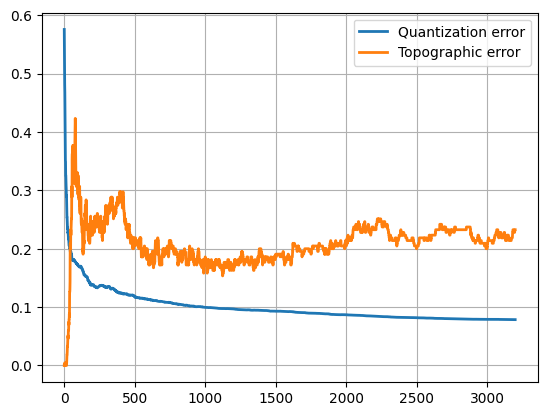

In [44]:
plt.plot(som._quantization_error,linewidth=2,label='Quantization error')
plt.plot(som._topographic_error,linewidth=2, label='Topographic error')
plt.legend()
plt.grid()

In [45]:
som._learning_rate = lr_finetuning #Para mudar a taxa de aprendizado durante o período de finetuning 

som.train_random(X, finetuning_time, verbose=True)


 [ 32000 / 32000 ] 100% - 0:00:00 left 
 quantization error: 0.08401006290248024


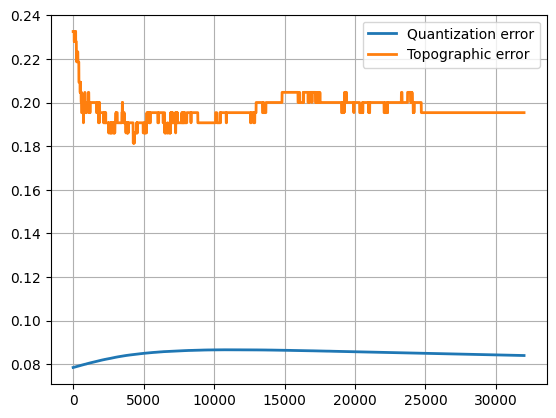

In [47]:
plt.plot(som._quantization_error,linewidth=2,label='Quantization error')
plt.plot(som._topographic_error,linewidth=2, label='Topographic error')
plt.legend()
plt.grid()

Após uma revisão na internet, encontrei uma relação razoável para o número de neurônios. Escolhi então usar essa relação para selecionar o número de neurônio que se daria por 5*sqrt(N), sendo N o número de amostras. Como se trata de uma rede, considerei o mesmo número de neurônios pela largura e altura tomando m=n=sqrt(5*sqrt(N))

Os parâmetros taxa de aprendizagem e número de iterações foram modificados. Na fase de ordenação, devemos ter uma taxa de aprendizagem alta e poucas iterações, fazendo com que mude rapidamente os pesos no treinamento. Sendo assim foram escolhidos 0.1 para a taxa de aprendizagem e 50*m*n para o número de iterações. Esses valores foram escolhidos de tal maneira que a taxa da fase de ajuste fino deva ser > 0.02 e, portanto, foi escolhido um valor de 0.001. O número de iterações foi escolhido de maneira que seja menor que 500 vezes o número de neurônios.

Na fase de ordenação buscamos exatamente o contrário, uma mudança devagar nos pesos ao longo de muitas iterações. Sendo assim foi escolhido um valor pequena para a taxa de aprendizagem de 0.001 < 0.02 e um número de iterações de 500 vezes o número de neurônios.

Ademais, é possível, analisar que o erro de quantização (QE) cai exponencialmente, como esperado, mas o erro topográfico (TE) cresce primeiro e depois decresce e se estabiliza. Isso ocorre pois o raio de vizinhança é grande nas primeiras iterações, não condizendo com a distribuição dos dados, aumentando o erro. Conforme passam as iterações, o raio cai e a vizinhança começa a se aproximar da distribuição original dos dados, explicando assim pq ele cai um pouco e depois se estabiliza.


##### 2. Modifique a topologia da rede. Teste diferentes valores e avalie o resultado.

In [ ]:
#decay function 

def decay_fcn(lr,actual_t,max_t):
    '''
    Função para decaimento da taxa de aprendizado. 
    
    ## INPUTS:
    lr - Taxa de aprendizado inicial
    actual_t - Tempo atual da iteração
    max_t - Tempo máximo da iteração

    ## OUTPUT:
    - taxa de aprendizado atualizada.
    '''

    new_lr = lr/(1 + 2*actual_t/max_t)

    return new_lr


m = int(np.sqrt(5*np.sqrt(values.shape[0]))) #Dimensão X do mapa de Kohonen
n = m #Dimensão Y do mapa de Kohonen
print("Dimensões do mapa de Kohonen: ", m, "x", n, ": ", m*n, "neurônios")
lr_ordering = 0.1 #Taxa de aprendizado - Ordering phase #! Alto > 0.02
lr_finetuning = 0.001 #Taxa de aprendizado - Finetuning phase #! Slide < 0.02

topology = "rectangular" #! A hexagonal é melhor pois permite um número maior de vizinhos, tornando mais uniforme o aprendizado.

ordering_time = 50 * m * n #! Número menor para a fase de ordenaçao.
finetuning_time = 500 * m * n #! formula nos Slides
decay_fun =  decay_fcn 


#Dimensão do vetor de entrada
input_len = values.shape[1]

X = minmax_scale(values)





Dimensões do mapa de Kohonen:  8 x 8 :  64 neurônios


In [ ]:
som = MiniSom(m,n,input_len,learning_rate=lr_ordering,topology=topology,decay_function=decay_fcn)
som.pca_weights_init(values)

som.train_random(X, ordering_time, verbose=True)

 [ 3200 / 3200 ] 100% - 0:00:00 left 
 quantization error: 0.438421409881507


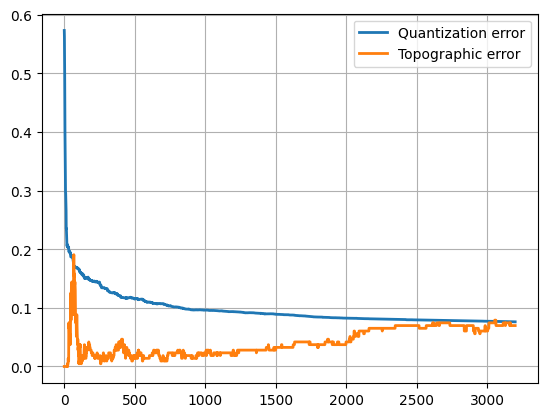

In [50]:
plt.plot(som._quantization_error,linewidth=2,label='Quantization error')
plt.plot(som._topographic_error,linewidth=2, label='Topographic error')
plt.legend()
plt.grid()

In [51]:
som._learning_rate = lr_finetuning #Para mudar a taxa de aprendizado durante o período de finetuning 

som.train_random(X, finetuning_time, verbose=True)

 [ 32000 / 32000 ] 100% - 0:00:00 left 
 quantization error: 0.08131763160733232


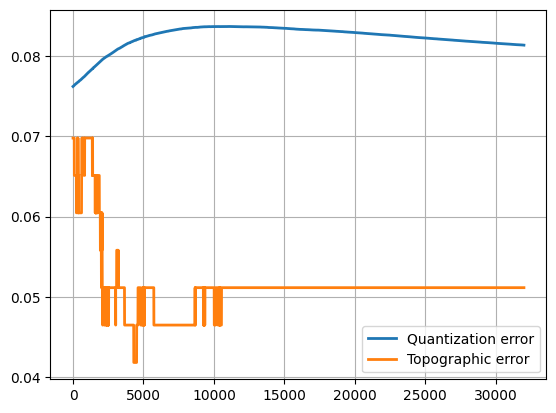

In [52]:
plt.plot(som._quantization_error,linewidth=2,label='Quantization error')
plt.plot(som._topographic_error,linewidth=2, label='Topographic error')
plt.legend()
plt.grid()

O erro quantizado entre os modelos treinados com topologias diferentes é aproximadamente o mesmo, em torno de 0.08. Entretanto o erro topográfico é bem maior na topologia hexagonal. Isso se dá ao fato deles usarem o mesmo sigma e terem número de vizinhos diferentes. Como a topologia hexagonal é mais densa, necessita começar com um raio um pouco maior.

##### 3. Modifique a normalização dos dados de entrada e avalie o resultado obtido. Esta mudança tem algum efeito no mapa gerado?

In [92]:
#decay function 

def decay_fcn(lr,actual_t,max_t):
    '''
    Função para decaimento da taxa de aprendizado. 
    
    ## INPUTS:
    lr - Taxa de aprendizado inicial
    actual_t - Tempo atual da iteração
    max_t - Tempo máximo da iteração

    ## OUTPUT:
    - taxa de aprendizado atualizada.
    '''

    new_lr = lr/(1 + 2*actual_t/max_t)

    return new_lr


m = int(np.sqrt(5*np.sqrt(values.shape[0])))
n = m #Dimensão Y do mapa de Kohonen
print("Dimensões do mapa de Kohonen: ", m, "x", n, ": ", m*n, "neurônios")
lr_ordering = 0.1 #Taxa de aprendizado - Ordering phase #! Alto > 0.02
lr_finetuning = 0.001 #Taxa de aprendizado - Finetuning phase #! Slide < 0.02

topology = "hexagonal" #! A hexagonal é melhor pois permite um número maior de vizinhos, tornando mais uniforme o aprendizado.

ordering_time = 50 * m * n #! Número menor para a fase de ordenaçao.
finetuning_time = 500 * m * n #! formula nos Slides
decay_fun =  decay_fcn 


#Dimensão do vetor de entrada
input_len = values.shape[1]

# X = minmax_scale(values)
std_scaler = StandardScaler()
X = std_scaler.fit_transform(values)
print(X.shape)



Dimensões do mapa de Kohonen:  8 x 8 :  64 neurônios
(215, 5)


In [93]:
som = MiniSom(m,n,input_len,learning_rate=lr_ordering,topology=topology,decay_function=decay_fcn)
som.pca_weights_init(values)

som.train_random(X, ordering_time, verbose=True)

 [ 3200 / 3200 ] 100% - 0:00:00 left 
 quantization error: 0.4378875063409221


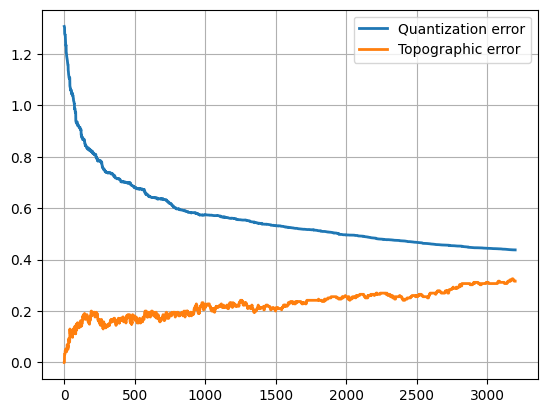

In [94]:
plt.plot(som._quantization_error,linewidth=2,label='Quantization error')
plt.plot(som._topographic_error,linewidth=2, label='Topographic error')
plt.legend()
plt.grid()

In [95]:
som._learning_rate = lr_finetuning #Para mudar a taxa de aprendizado durante o período de finetuning 

som.train_random(X, finetuning_time, verbose=True)

 [ 32000 / 32000 ] 100% - 0:00:00 left 
 quantization error: 0.46354909497833585


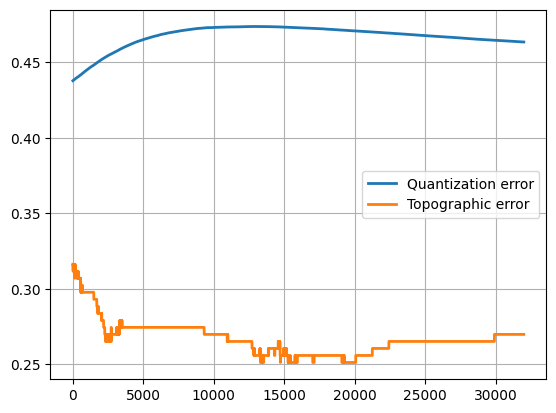

In [96]:
plt.plot(som._quantization_error,linewidth=2,label='Quantization error')
plt.plot(som._topographic_error,linewidth=2, label='Topographic error')
plt.legend()
plt.grid()

O fato dos dados estarem padronizados, ou seja, não estarem normalizados e começar o algoritmo utilizando tamanho do raio de vizinhança igual a 1 torna o aprendizado problemático. Nas primeiras iterações o algoritmo não encontrará muitos dados para aproximar os neurônios e conforme o raio for crescendo a função de vizinhança vai diminuindo seu valor, já que é do tipo gaussiana. Portanto, as atualizações nas últimas iterações são pouco expressivas. Isso tudo torna o aprendizado ruim e explica o erro alto.

##### 4. Modifique o processo de treinamento durante a fase de ordenação. Avalie o resultado gerado.

In [102]:
#decay function 

def decay_fcn(lr,actual_t,max_t):
    '''
    Função para decaimento da taxa de aprendizado. 
    
    ## INPUTS:
    lr - Taxa de aprendizado inicial
    actual_t - Tempo atual da iteração
    max_t - Tempo máximo da iteração

    ## OUTPUT:
    - taxa de aprendizado atualizada.
    '''

    new_lr = lr/(1 + 2*actual_t/max_t)

    return new_lr


m = int(np.sqrt(5*np.sqrt(values.shape[0]))) #Dimensão X do mapa de Kohonen
n = m #Dimensão Y do mapa de Kohonen
print("Dimensões do mapa de Kohonen: ", m, "x", n, ": ", m*n, "neurônios")
lr_ordering = 0.1 #Taxa de aprendizado - Ordering phase #! Alto > 0.02
lr_finetuning = 0.001 #Taxa de aprendizado - Finetuning phase #! Slide < 0.02

topology = "hexagonal" #! A hexagonal é melhor pois permite um número maior de vizinhos, tornando mais uniforme o aprendizado.

ordering_time = 500 #! Número menor para a fase de ordenaçao.
finetuning_time = 10000 #! formula nos Slides
decay_fun =  decay_fcn 

#Dimensão do vetor de entrada
input_len = values.shape[1]

X = minmax_scale(values)



Dimensões do mapa de Kohonen:  8 x 8 :  64 neurônios


In [103]:
som = MiniSom(m,n,input_len,learning_rate=lr_ordering,topology=topology,decay_function=decay_fcn)
som.pca_weights_init(values)

som.train_random(X, ordering_time, verbose=True)

 [ 500 / 500 ] 100% - 0:00:00 left 
 quantization error: 0.13642499035177982


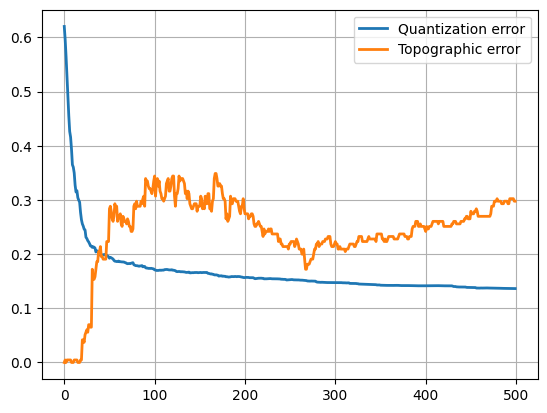

In [104]:
plt.plot(som._quantization_error,linewidth=2,label='Quantization error')
plt.plot(som._topographic_error,linewidth=2, label='Topographic error')
plt.legend()
plt.grid()

In [107]:
#decay function 

def decay_fcn(lr,actual_t,max_t):
    '''
    Função para decaimento da taxa de aprendizado. 
    
    ## INPUTS:
    lr - Taxa de aprendizado inicial
    actual_t - Tempo atual da iteração
    max_t - Tempo máximo da iteração

    ## OUTPUT:
    - taxa de aprendizado atualizada.
    '''

    new_lr = lr/(1 + 2*actual_t/max_t)

    return new_lr


m = int(np.sqrt(5*np.sqrt(values.shape[0]))) #Dimensão X do mapa de Kohonen
n = m #Dimensão Y do mapa de Kohonen
print("Dimensões do mapa de Kohonen: ", m, "x", n, ": ", m*n, "neurônios")
lr_ordering = 0.1 #Taxa de aprendizado - Ordering phase #! Alto > 0.02
lr_finetuning = 0.001 #Taxa de aprendizado - Finetuning phase #! Slide < 0.02

topology = "hexagonal" #! A hexagonal é melhor pois permite um número maior de vizinhos, tornando mais uniforme o aprendizado.

ordering_time = 2 * 500 #! Número menor para a fase de ordenaçao.
finetuning_time = 10000 #! formula nos Slides
decay_fun =  decay_fcn 

#Dimensão do vetor de entrada
input_len = values.shape[1]

X = minmax_scale(values)



Dimensões do mapa de Kohonen:  8 x 8 :  64 neurônios


In [108]:
som = MiniSom(m,n,input_len,learning_rate=lr_ordering,topology=topology,decay_function=decay_fcn)
som.pca_weights_init(values)

som.train_random(X, ordering_time, verbose=True)

 [ 1000 / 1000 ] 100% - 0:00:00 left 
 quantization error: 0.10967290191794969


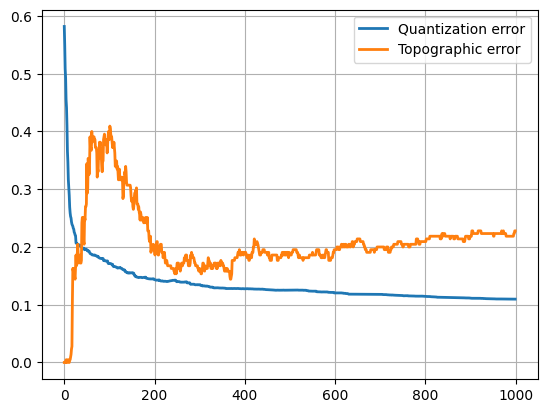

In [109]:
plt.plot(som._quantization_error,linewidth=2,label='Quantization error')
plt.plot(som._topographic_error,linewidth=2, label='Topographic error')
plt.legend()
plt.grid()

In [111]:
#decay function 

def decay_fcn(lr,actual_t,max_t):
    '''
    Função para decaimento da taxa de aprendizado. 
    
    ## INPUTS:
    lr - Taxa de aprendizado inicial
    actual_t - Tempo atual da iteração
    max_t - Tempo máximo da iteração

    ## OUTPUT:
    - taxa de aprendizado atualizada.
    '''

    new_lr = lr/(1 + 2*actual_t/max_t)

    return new_lr


m = int(np.sqrt(5*np.sqrt(values.shape[0]))) #Dimensão X do mapa de Kohonen
n = m #Dimensão Y do mapa de Kohonen
print("Dimensões do mapa de Kohonen: ", m, "x", n, ": ", m*n, "neurônios")
lr_ordering = 0.1 #Taxa de aprendizado - Ordering phase #! Alto > 0.02
lr_finetuning = 0.001 #Taxa de aprendizado - Finetuning phase #! Slide < 0.02

topology = "hexagonal" #! A hexagonal é melhor pois permite um número maior de vizinhos, tornando mais uniforme o aprendizado.

ordering_time = 3 * 500 #! Número menor para a fase de ordenaçao.
finetuning_time = 10000 #! formula nos Slides
decay_fun =  decay_fcn 

#Dimensão do vetor de entrada
input_len = values.shape[1]

X = minmax_scale(values)



Dimensões do mapa de Kohonen:  8 x 8 :  64 neurônios


In [112]:
som = MiniSom(m,n,input_len,learning_rate=lr_ordering,topology=topology,decay_function=decay_fcn)
som.pca_weights_init(values)

som.train_random(X, ordering_time, verbose=True)

 [ 1500 / 1500 ] 100% - 0:00:00 left 
 quantization error: 0.09510397323692932


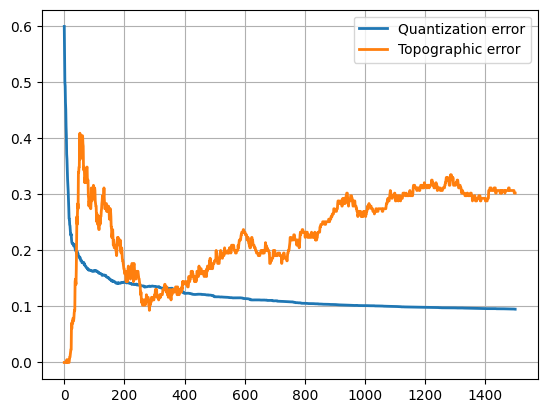

In [113]:
plt.plot(som._quantization_error,linewidth=2,label='Quantization error')
plt.plot(som._topographic_error,linewidth=2, label='Topographic error')
plt.legend()
plt.grid()

In [114]:
#decay function 

def decay_fcn(lr,actual_t,max_t):
    '''
    Função para decaimento da taxa de aprendizado. 
    
    ## INPUTS:
    lr - Taxa de aprendizado inicial
    actual_t - Tempo atual da iteração
    max_t - Tempo máximo da iteração

    ## OUTPUT:
    - taxa de aprendizado atualizada.
    '''

    new_lr = lr/(1 + 2*actual_t/max_t)

    return new_lr


m = int(np.sqrt(5*np.sqrt(values.shape[0]))) #Dimensão X do mapa de Kohonen
n = m #Dimensão Y do mapa de Kohonen
print("Dimensões do mapa de Kohonen: ", m, "x", n, ": ", m*n, "neurônios")
lr_ordering = 0.1 #Taxa de aprendizado - Ordering phase #! Alto > 0.02
lr_finetuning = 0.001 #Taxa de aprendizado - Finetuning phase #! Slide < 0.02

topology = "hexagonal" #! A hexagonal é melhor pois permite um número maior de vizinhos, tornando mais uniforme o aprendizado.

ordering_time = 1000 #! Número menor para a fase de ordenaçao.
finetuning_time = 10000 #! formula nos Slides
decay_fun =  decay_fcn 

#Dimensão do vetor de entrada
input_len = values.shape[1]

X = minmax_scale(values)



Dimensões do mapa de Kohonen:  8 x 8 :  64 neurônios


In [115]:
som = MiniSom(m,n,input_len,learning_rate=lr_ordering,topology=topology,decay_function=decay_fcn)
som.pca_weights_init(values)

som.train_random(X, ordering_time, verbose=True)

 [ 1000 / 1000 ] 100% - 0:00:00 left 
 quantization error: 0.10643629053142144


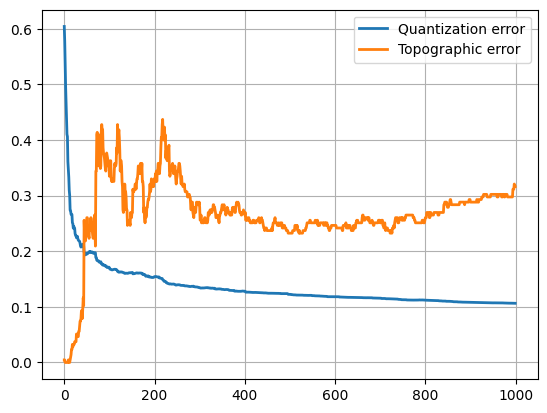

In [116]:
plt.plot(som._quantization_error,linewidth=2,label='Quantization error')
plt.plot(som._topographic_error,linewidth=2, label='Topographic error')
plt.legend()
plt.grid()

In [117]:
#decay function 

def decay_fcn(lr,actual_t,max_t):
    '''
    Função para decaimento da taxa de aprendizado. 
    
    ## INPUTS:
    lr - Taxa de aprendizado inicial
    actual_t - Tempo atual da iteração
    max_t - Tempo máximo da iteração

    ## OUTPUT:
    - taxa de aprendizado atualizada.
    '''

    new_lr = lr/(1 + 2*actual_t/max_t)

    return new_lr


m = int(np.sqrt(5*np.sqrt(values.shape[0]))) #Dimensão X do mapa de Kohonen
n = m #Dimensão Y do mapa de Kohonen
print("Dimensões do mapa de Kohonen: ", m, "x", n, ": ", m*n, "neurônios")
lr_ordering = 0.01 #Taxa de aprendizado - Ordering phase #! Alto > 0.02
lr_finetuning = 0.001 #Taxa de aprendizado - Finetuning phase #! Slide < 0.02

topology = "hexagonal" #! A hexagonal é melhor pois permite um número maior de vizinhos, tornando mais uniforme o aprendizado.

ordering_time = 1000 #! Número menor para a fase de ordenaçao.
finetuning_time = 10000 #! formula nos Slides
decay_fun =  decay_fcn 

#Dimensão do vetor de entrada
input_len = values.shape[1]

X = minmax_scale(values)



Dimensões do mapa de Kohonen:  8 x 8 :  64 neurônios


In [118]:
som = MiniSom(m,n,input_len,learning_rate=lr_ordering,topology=topology,decay_function=decay_fcn)
som.pca_weights_init(values)

som.train_random(X, ordering_time, verbose=True)

 [ 1000 / 1000 ] 100% - 0:00:00 left 
 quantization error: 0.19911656205880565


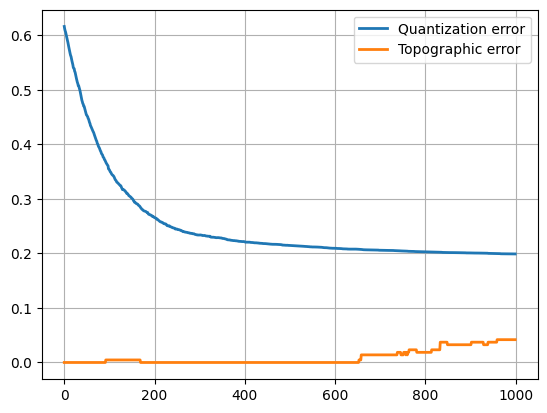

In [119]:
plt.plot(som._quantization_error,linewidth=2,label='Quantization error')
plt.plot(som._topographic_error,linewidth=2, label='Topographic error')
plt.legend()
plt.grid()

In [120]:
#decay function 

def decay_fcn(lr,actual_t,max_t):
    '''
    Função para decaimento da taxa de aprendizado. 
    
    ## INPUTS:
    lr - Taxa de aprendizado inicial
    actual_t - Tempo atual da iteração
    max_t - Tempo máximo da iteração

    ## OUTPUT:
    - taxa de aprendizado atualizada.
    '''

    new_lr = lr/(1 + 2*actual_t/max_t)

    return new_lr


m = int(np.sqrt(5*np.sqrt(values.shape[0]))) #Dimensão X do mapa de Kohonen
n = m #Dimensão Y do mapa de Kohonen
print("Dimensões do mapa de Kohonen: ", m, "x", n, ": ", m*n, "neurônios")
lr_ordering = 0.001 #Taxa de aprendizado - Ordering phase #! Alto > 0.02
lr_finetuning = 0.001 #Taxa de aprendizado - Finetuning phase #! Slide < 0.02

topology = "hexagonal" #! A hexagonal é melhor pois permite um número maior de vizinhos, tornando mais uniforme o aprendizado.

ordering_time = 1000 #! Número menor para a fase de ordenaçao.
finetuning_time = 10000 #! formula nos Slides
decay_fun =  decay_fcn 

#Dimensão do vetor de entrada
input_len = values.shape[1]

X = minmax_scale(values)



Dimensões do mapa de Kohonen:  8 x 8 :  64 neurônios


In [121]:
som = MiniSom(m,n,input_len,learning_rate=lr_ordering,topology=topology,decay_function=decay_fcn)
som.pca_weights_init(values)

som.train_random(X, ordering_time, verbose=True)

 [ 1000 / 1000 ] 100% - 0:00:00 left 
 quantization error: 0.44602261795296905


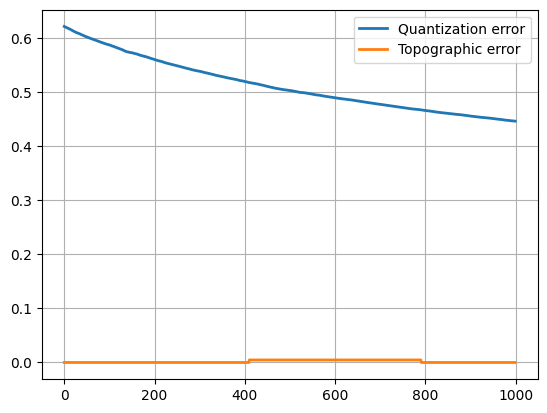

In [122]:
plt.plot(som._quantization_error,linewidth=2,label='Quantization error')
plt.plot(som._topographic_error,linewidth=2, label='Topographic error')
plt.legend()
plt.grid()

Fizeram-se 2 exprimentos na etapa de ordenação. Fixando a taxa de aprendizagem e variando o número de iterações e fixando o número de iterações e variando a taxa de aprendizagem.  

O primeiro experimento teve como objetivo estudar o impacto da escolha do número de iterações. Foi testado valores de 500, 1000 e 1500 iterações com a taxa de aprendizagem de 0.1. Pelos gráficos, podemos ver que conforme o número de iterações aumenta na etapa de ordenação o erro de quantização diminui, ou seja, os neurônios se adaptam melhor aos dados. Já o erro topográfico, por sua vez, apresenta um comportamento diferente. O erro topográfico mede o erro os vizinhos. Ele verifica se o BMU 1 é vizinho do BMU 2 e mede uma média dessa contagem. Como a learning rate está alta, os neurônios se ajustam globalmente e fortemente, então eles se ajustam rapidamente aos dados mais próximos, explicando o decaimento rápido do erro. Entretanto, ele decai rápido demais e como a learning rate é rápido neste momento, após chegar em um erro mínimo ele continua ajustando fortemente e desorganizando o mapa que já chegou em seu mínimo, aumentando assim o erro. Podemos ver que conforme o número de iterações aumenta, o erro topográfico aumenta muito também.

Como já estudam a escolha do número de iterações, foi escolhido o valor de 1000 fixo nesse segundo experimento, já que ele teve o melhor balanço entre erro quantizado e topográfico. Nessa segunda etapa, variamos a taxa de aprendizagem. Podemos extrair duas observações importantes dos gráficos. Primeiramente, o erro topográfico se aproxima de zero conforme a taxa de aprendizado diminui. Isso retifica o observado no experimento anterior, já que a rede começa com neurônios próximos dos dados e, portanto, preservando a vizinhança de dados próximos. Isso fica claro pois diminuindo a taxa de aprendizagem a atualização dos pesos é quase nula, e o erro topográfico sendo zero, significa que os vizinhos estão corretos. Entretanto, o erro quantizado aumenta conforme a taxa diminui. Isso ocorre porque o neurônio vencedor não consegue se aproximar dos dados, pois a taxa de aprendizagem baixa não permite uma atualização expressiva. Explicando o erro mais alto conforme a taxa de aprendizagem diminui.

##### 5. Modifique o processo de treinamento durante a fase de ajuste fino. Avalie o resultado gerado.

Dimensões do mapa de Kohonen:  8 x 8 :  64 neurônios
 [ 500 / 500 ] 100% - 0:00:00 left 
 quantization error: 0.12929989280771573


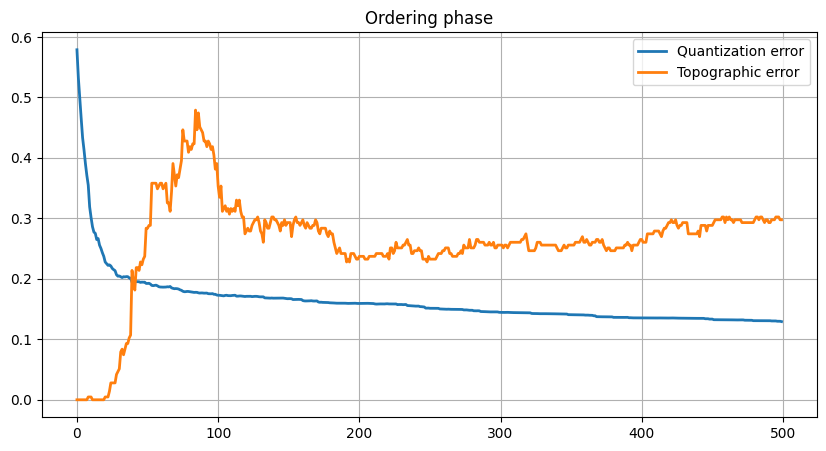

 [ 10000 / 10000 ] 100% - 0:00:00 left 
 quantization error: 0.10185403919343765


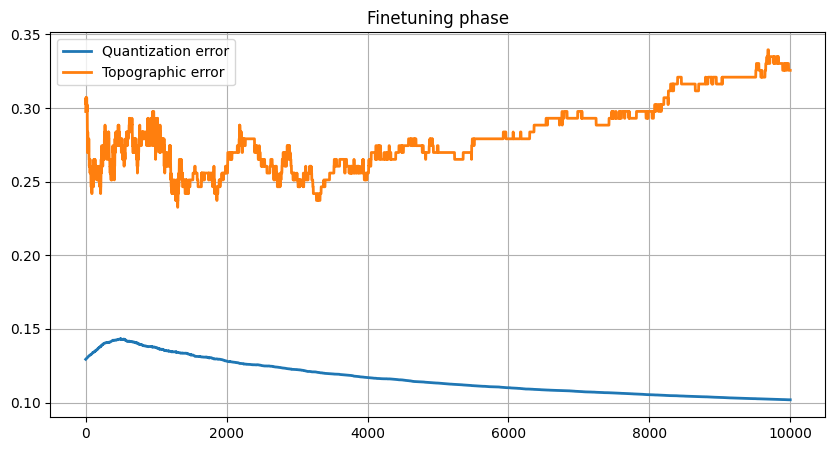

In [126]:
#decay function 

def decay_fcn(lr,actual_t,max_t):
    '''
    Função para decaimento da taxa de aprendizado. 
    
    ## INPUTS:
    lr - Taxa de aprendizado inicial
    actual_t - Tempo atual da iteração
    max_t - Tempo máximo da iteração

    ## OUTPUT:
    - taxa de aprendizado atualizada.
    '''

    new_lr = lr/(1 + 2*actual_t/max_t)

    return new_lr


m = int(np.sqrt(5*np.sqrt(values.shape[0]))) #Dimensão X do mapa de Kohonen
n = m #Dimensão Y do mapa de Kohonen
print("Dimensões do mapa de Kohonen: ", m, "x", n, ": ", m*n, "neurônios")
lr_ordering = 0.1 #Taxa de aprendizado - Ordering phase #! Alto > 0.02
lr_finetuning = 0.01 #Taxa de aprendizado - Finetuning phase #! Slide < 0.02

topology = "hexagonal" #! A hexagonal é melhor pois permite um número maior de vizinhos, tornando mais uniforme o aprendizado.

ordering_time = 500 #! Número menor para a fase de ordenaçao.
finetuning_time = 10000 #! formula nos Slides
decay_fun =  decay_fcn 

#Dimensão do vetor de entrada
input_len = values.shape[1]

X = minmax_scale(values)

som = MiniSom(m,n,input_len,learning_rate=lr_ordering,topology=topology,decay_function=decay_fcn)
som.pca_weights_init(values)

som.train_random(X, ordering_time, verbose=True)

fig = plt.figure(figsize=(10, 5))
plt.title('Ordering phase')
plt.plot(som._quantization_error,linewidth=2,label='Quantization error')
plt.plot(som._topographic_error,linewidth=2, label='Topographic error')
plt.legend()
plt.grid()
plt.show()

som._learning_rate = lr_finetuning #Para mudar a taxa de aprendizado durante o período de finetuning 

som.train_random(X, finetuning_time, verbose=True)

fig = plt.figure(figsize=(10, 5))
plt.title('Finetuning phase')
plt.plot(som._quantization_error,linewidth=2,label='Quantization error')
plt.plot(som._topographic_error,linewidth=2, label='Topographic error')
plt.legend()
plt.grid()
plt.show()

Dimensões do mapa de Kohonen:  8 x 8 :  64 neurônios
 [ 500 / 500 ] 100% - 0:00:00 left 
 quantization error: 0.1319284321828917


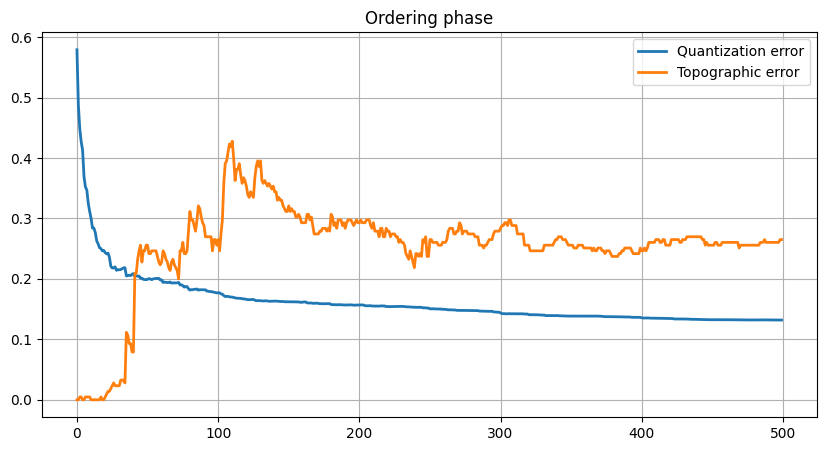

 [ 10000 / 10000 ] 100% - 0:00:00 left 
 quantization error: 0.1314211163638254


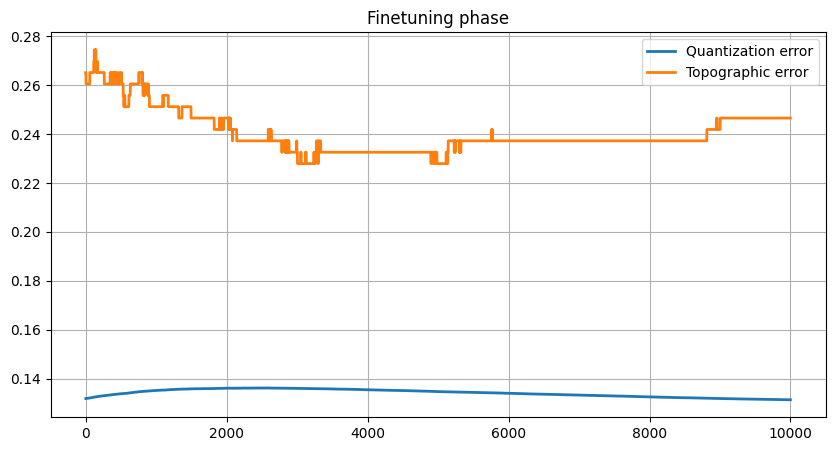

In [127]:
#decay function 

def decay_fcn(lr,actual_t,max_t):
    '''
    Função para decaimento da taxa de aprendizado. 
    
    ## INPUTS:
    lr - Taxa de aprendizado inicial
    actual_t - Tempo atual da iteração
    max_t - Tempo máximo da iteração

    ## OUTPUT:
    - taxa de aprendizado atualizada.
    '''

    new_lr = lr/(1 + 2*actual_t/max_t)

    return new_lr


m = int(np.sqrt(5*np.sqrt(values.shape[0]))) #Dimensão X do mapa de Kohonen
n = m #Dimensão Y do mapa de Kohonen
print("Dimensões do mapa de Kohonen: ", m, "x", n, ": ", m*n, "neurônios")
lr_ordering = 0.1 #Taxa de aprendizado - Ordering phase #! Alto > 0.02
lr_finetuning = 0.001 #Taxa de aprendizado - Finetuning phase #! Slide < 0.02

topology = "hexagonal" #! A hexagonal é melhor pois permite um número maior de vizinhos, tornando mais uniforme o aprendizado.

ordering_time = 500 #! Número menor para a fase de ordenaçao.
finetuning_time = 10000 #! formula nos Slides
decay_fun =  decay_fcn 

#Dimensão do vetor de entrada
input_len = values.shape[1]

X = minmax_scale(values)

som = MiniSom(m,n,input_len,learning_rate=lr_ordering,topology=topology,decay_function=decay_fcn)
som.pca_weights_init(values)

som.train_random(X, ordering_time, verbose=True)

fig = plt.figure(figsize=(10, 5))
plt.title('Ordering phase')
plt.plot(som._quantization_error,linewidth=2,label='Quantization error')
plt.plot(som._topographic_error,linewidth=2, label='Topographic error')
plt.legend()
plt.grid()
plt.show()

som._learning_rate = lr_finetuning #Para mudar a taxa de aprendizado durante o período de finetuning 

som.train_random(X, finetuning_time, verbose=True)

fig = plt.figure(figsize=(10, 5))
plt.title('Finetuning phase')
plt.plot(som._quantization_error,linewidth=2,label='Quantization error')
plt.plot(som._topographic_error,linewidth=2, label='Topographic error')
plt.legend()
plt.grid()
plt.show()

Dimensões do mapa de Kohonen:  8 x 8 :  64 neurônios
 [ 500 / 500 ] 100% - 0:00:00 left 
 quantization error: 0.13267736287831097


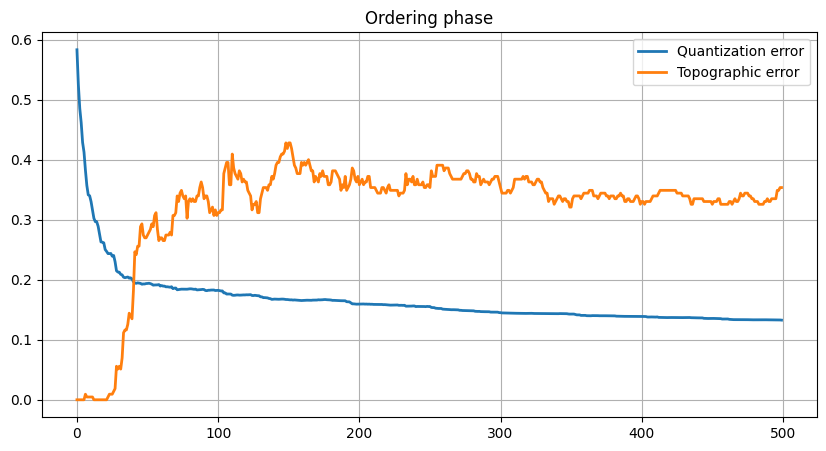

 [ 10000 / 10000 ] 100% - 0:00:00 left 
 quantization error: 0.13341696043670478


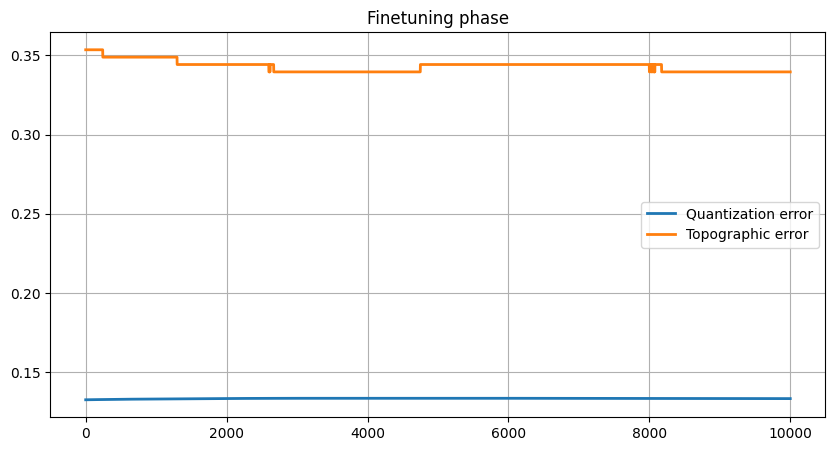

In [128]:
#decay function 

def decay_fcn(lr,actual_t,max_t):
    '''
    Função para decaimento da taxa de aprendizado. 
    
    ## INPUTS:
    lr - Taxa de aprendizado inicial
    actual_t - Tempo atual da iteração
    max_t - Tempo máximo da iteração

    ## OUTPUT:
    - taxa de aprendizado atualizada.
    '''

    new_lr = lr/(1 + 2*actual_t/max_t)

    return new_lr


m = int(np.sqrt(5*np.sqrt(values.shape[0]))) #Dimensão X do mapa de Kohonen
n = m #Dimensão Y do mapa de Kohonen
print("Dimensões do mapa de Kohonen: ", m, "x", n, ": ", m*n, "neurônios")
lr_ordering = 0.1 #Taxa de aprendizado - Ordering phase #! Alto > 0.02
lr_finetuning = 0.0001 #Taxa de aprendizado - Finetuning phase #! Slide < 0.02

topology = "hexagonal" #! A hexagonal é melhor pois permite um número maior de vizinhos, tornando mais uniforme o aprendizado.

ordering_time = 500 #! Número menor para a fase de ordenaçao.
finetuning_time = 10000 #! formula nos Slides
decay_fun =  decay_fcn 

#Dimensão do vetor de entrada
input_len = values.shape[1]

X = minmax_scale(values)

som = MiniSom(m,n,input_len,learning_rate=lr_ordering,topology=topology,decay_function=decay_fcn)
som.pca_weights_init(values)

som.train_random(X, ordering_time, verbose=True)

fig = plt.figure(figsize=(10, 5))
plt.title('Ordering phase')
plt.plot(som._quantization_error,linewidth=2,label='Quantization error')
plt.plot(som._topographic_error,linewidth=2, label='Topographic error')
plt.legend()
plt.grid()
plt.show()

som._learning_rate = lr_finetuning #Para mudar a taxa de aprendizado durante o período de finetuning 

som.train_random(X, finetuning_time, verbose=True)

fig = plt.figure(figsize=(10, 5))
plt.title('Finetuning phase')
plt.plot(som._quantization_error,linewidth=2,label='Quantization error')
plt.plot(som._topographic_error,linewidth=2, label='Topographic error')
plt.legend()
plt.grid()
plt.show()

Dimensões do mapa de Kohonen:  8 x 8 :  64 neurônios
 [ 500 / 500 ] 100% - 0:00:00 left 
 quantization error: 0.12745817455954633


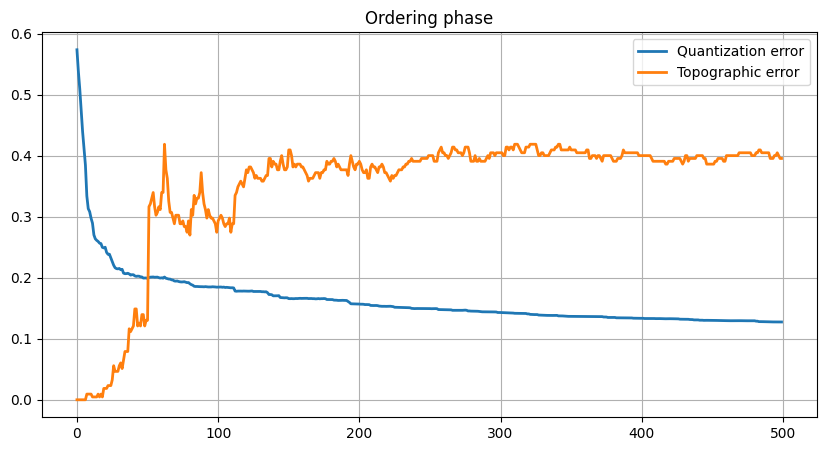

 [ 1000 / 1000 ] 100% - 0:00:00 left 
 quantization error: 0.12782233454725353


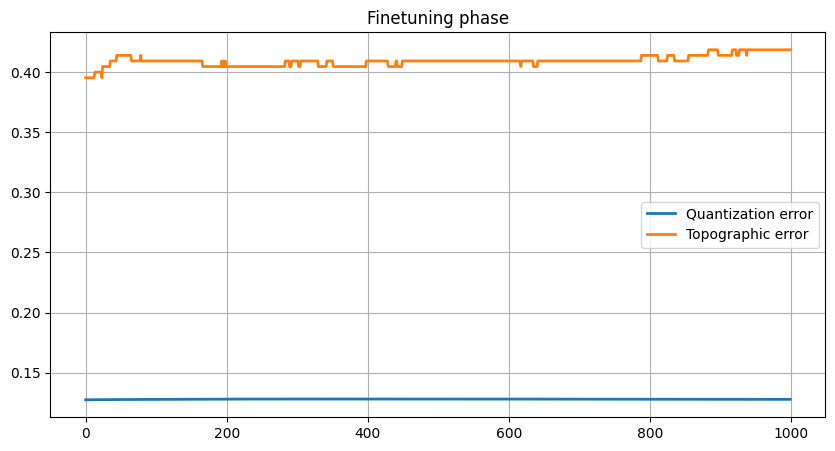

In [129]:
#decay function 

def decay_fcn(lr,actual_t,max_t):
    '''
    Função para decaimento da taxa de aprendizado. 
    
    ## INPUTS:
    lr - Taxa de aprendizado inicial
    actual_t - Tempo atual da iteração
    max_t - Tempo máximo da iteração

    ## OUTPUT:
    - taxa de aprendizado atualizada.
    '''

    new_lr = lr/(1 + 2*actual_t/max_t)

    return new_lr


m = int(np.sqrt(5*np.sqrt(values.shape[0]))) #Dimensão X do mapa de Kohonen
n = m #Dimensão Y do mapa de Kohonen
print("Dimensões do mapa de Kohonen: ", m, "x", n, ": ", m*n, "neurônios")
lr_ordering = 0.1 #Taxa de aprendizado - Ordering phase #! Alto > 0.02
lr_finetuning = 0.001 #Taxa de aprendizado - Finetuning phase #! Slide < 0.02

topology = "hexagonal" #! A hexagonal é melhor pois permite um número maior de vizinhos, tornando mais uniforme o aprendizado.

ordering_time = 500 #! Número menor para a fase de ordenaçao.
finetuning_time = 1000 #! formula nos Slides
decay_fun =  decay_fcn 

#Dimensão do vetor de entrada
input_len = values.shape[1]

X = minmax_scale(values)

som = MiniSom(m,n,input_len,learning_rate=lr_ordering,topology=topology,decay_function=decay_fcn)
som.pca_weights_init(values)

som.train_random(X, ordering_time, verbose=True)

fig = plt.figure(figsize=(10, 5))
plt.title('Ordering phase')
plt.plot(som._quantization_error,linewidth=2,label='Quantization error')
plt.plot(som._topographic_error,linewidth=2, label='Topographic error')
plt.legend()
plt.grid()
plt.show()

som._learning_rate = lr_finetuning #Para mudar a taxa de aprendizado durante o período de finetuning 

som.train_random(X, finetuning_time, verbose=True)

fig = plt.figure(figsize=(10, 5))
plt.title('Finetuning phase')
plt.plot(som._quantization_error,linewidth=2,label='Quantization error')
plt.plot(som._topographic_error,linewidth=2, label='Topographic error')
plt.legend()
plt.grid()
plt.show()

Dimensões do mapa de Kohonen:  8 x 8 :  64 neurônios
 [ 500 / 500 ] 100% - 0:00:00 left 
 quantization error: 0.12836863954560102


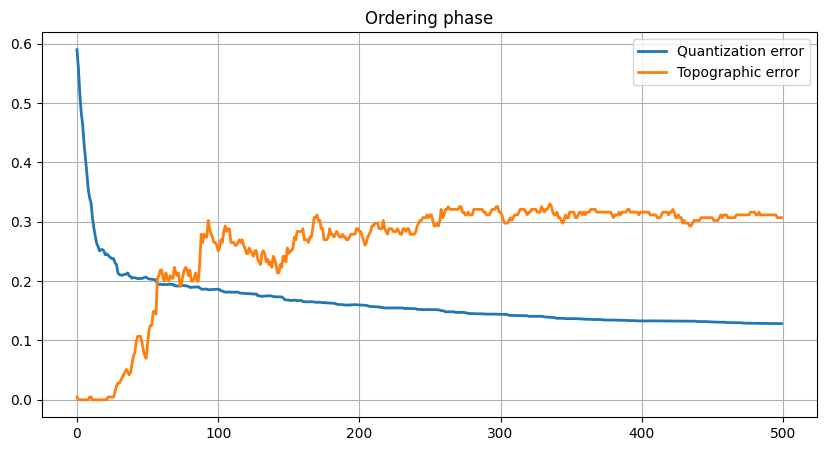

 [ 10000 / 10000 ] 100% - 0:00:00 left 
 quantization error: 0.1295382315149149


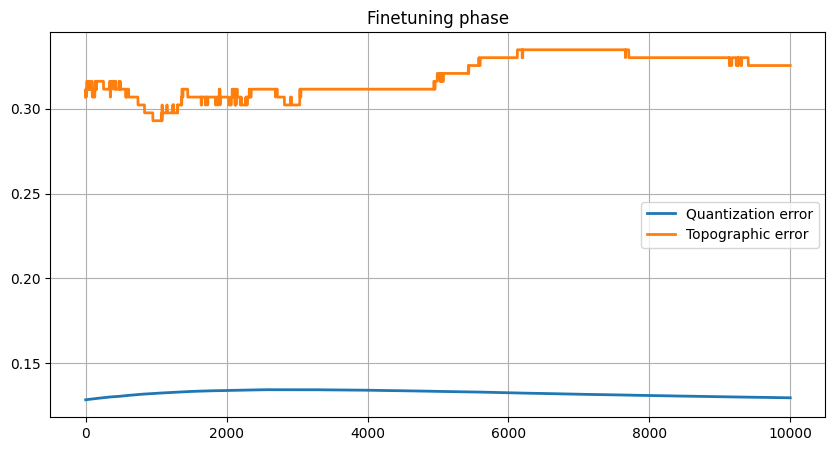

In [130]:
#decay function 

def decay_fcn(lr,actual_t,max_t):
    '''
    Função para decaimento da taxa de aprendizado. 
    
    ## INPUTS:
    lr - Taxa de aprendizado inicial
    actual_t - Tempo atual da iteração
    max_t - Tempo máximo da iteração

    ## OUTPUT:
    - taxa de aprendizado atualizada.
    '''

    new_lr = lr/(1 + 2*actual_t/max_t)

    return new_lr


m = int(np.sqrt(5*np.sqrt(values.shape[0]))) #Dimensão X do mapa de Kohonen
n = m #Dimensão Y do mapa de Kohonen
print("Dimensões do mapa de Kohonen: ", m, "x", n, ": ", m*n, "neurônios")
lr_ordering = 0.1 #Taxa de aprendizado - Ordering phase #! Alto > 0.02
lr_finetuning = 0.001 #Taxa de aprendizado - Finetuning phase #! Slide < 0.02

topology = "hexagonal" #! A hexagonal é melhor pois permite um número maior de vizinhos, tornando mais uniforme o aprendizado.

ordering_time = 500 #! Número menor para a fase de ordenaçao.
finetuning_time = 10000 #! formula nos Slides
decay_fun =  decay_fcn 

#Dimensão do vetor de entrada
input_len = values.shape[1]

X = minmax_scale(values)

som = MiniSom(m,n,input_len,learning_rate=lr_ordering,topology=topology,decay_function=decay_fcn)
som.pca_weights_init(values)

som.train_random(X, ordering_time, verbose=True)

fig = plt.figure(figsize=(10, 5))
plt.title('Ordering phase')
plt.plot(som._quantization_error,linewidth=2,label='Quantization error')
plt.plot(som._topographic_error,linewidth=2, label='Topographic error')
plt.legend()
plt.grid()
plt.show()

som._learning_rate = lr_finetuning #Para mudar a taxa de aprendizado durante o período de finetuning 

som.train_random(X, finetuning_time, verbose=True)

fig = plt.figure(figsize=(10, 5))
plt.title('Finetuning phase')
plt.plot(som._quantization_error,linewidth=2,label='Quantization error')
plt.plot(som._topographic_error,linewidth=2, label='Topographic error')
plt.legend()
plt.grid()
plt.show()

Dimensões do mapa de Kohonen:  8 x 8 :  64 neurônios
 [ 500 / 500 ] 100% - 0:00:00 left 
 quantization error: 0.12652984819293317


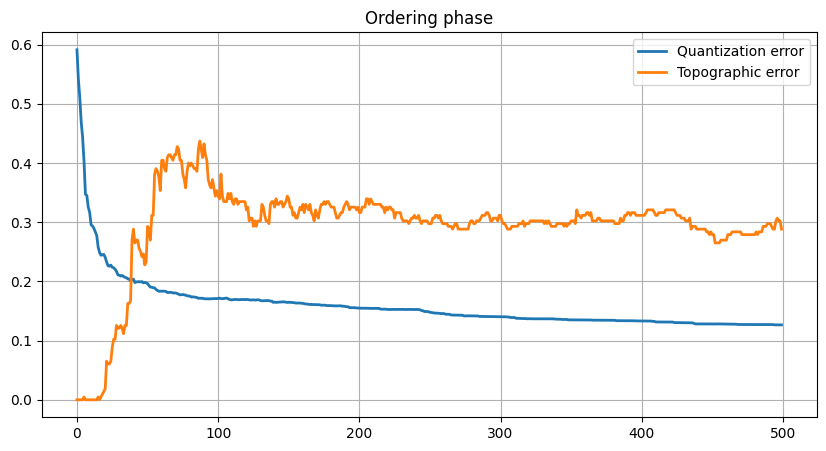

 [ 20000 / 20000 ] 100% - 0:00:00 left 
 quantization error: 0.11845555663165504


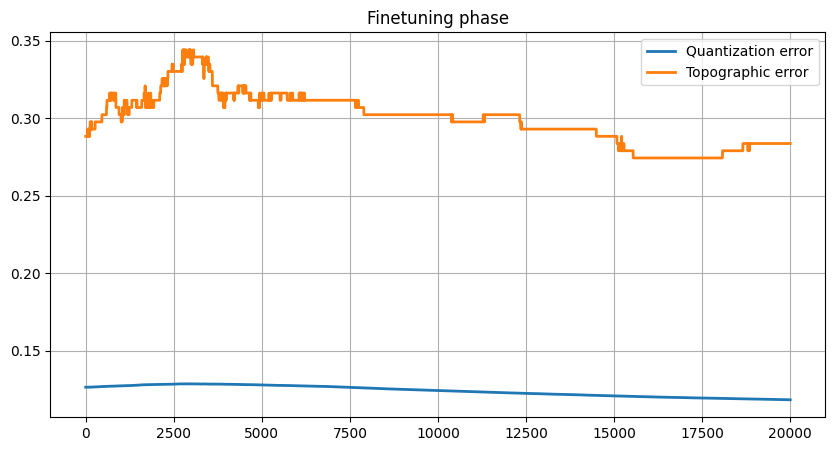

In [131]:
#decay function 

def decay_fcn(lr,actual_t,max_t):
    '''
    Função para decaimento da taxa de aprendizado. 
    
    ## INPUTS:
    lr - Taxa de aprendizado inicial
    actual_t - Tempo atual da iteração
    max_t - Tempo máximo da iteração

    ## OUTPUT:
    - taxa de aprendizado atualizada.
    '''

    new_lr = lr/(1 + 2*actual_t/max_t)

    return new_lr


m = int(np.sqrt(5*np.sqrt(values.shape[0]))) #Dimensão X do mapa de Kohonen
n = m #Dimensão Y do mapa de Kohonen
print("Dimensões do mapa de Kohonen: ", m, "x", n, ": ", m*n, "neurônios")
lr_ordering = 0.1 #Taxa de aprendizado - Ordering phase #! Alto > 0.02
lr_finetuning = 0.001 #Taxa de aprendizado - Finetuning phase #! Slide < 0.02

topology = "hexagonal" #! A hexagonal é melhor pois permite um número maior de vizinhos, tornando mais uniforme o aprendizado.

ordering_time = 500 #! Número menor para a fase de ordenaçao.
finetuning_time = 20000 #! formula nos Slides
decay_fun =  decay_fcn 

#Dimensão do vetor de entrada
input_len = values.shape[1]

X = minmax_scale(values)

som = MiniSom(m,n,input_len,learning_rate=lr_ordering,topology=topology,decay_function=decay_fcn)
som.pca_weights_init(values)

som.train_random(X, ordering_time, verbose=True)

fig = plt.figure(figsize=(10, 5))
plt.title('Ordering phase')
plt.plot(som._quantization_error,linewidth=2,label='Quantization error')
plt.plot(som._topographic_error,linewidth=2, label='Topographic error')
plt.legend()
plt.grid()
plt.show()

som._learning_rate = lr_finetuning #Para mudar a taxa de aprendizado durante o período de finetuning 

som.train_random(X, finetuning_time, verbose=True)

fig = plt.figure(figsize=(10, 5))
plt.title('Finetuning phase')
plt.plot(som._quantization_error,linewidth=2,label='Quantization error')
plt.plot(som._topographic_error,linewidth=2, label='Topographic error')
plt.legend()
plt.grid()
plt.show()

Dimensões do mapa de Kohonen:  8 x 8 :  64 neurônios
 [ 500 / 500 ] 100% - 0:00:00 left 
 quantization error: 0.12691825524675665


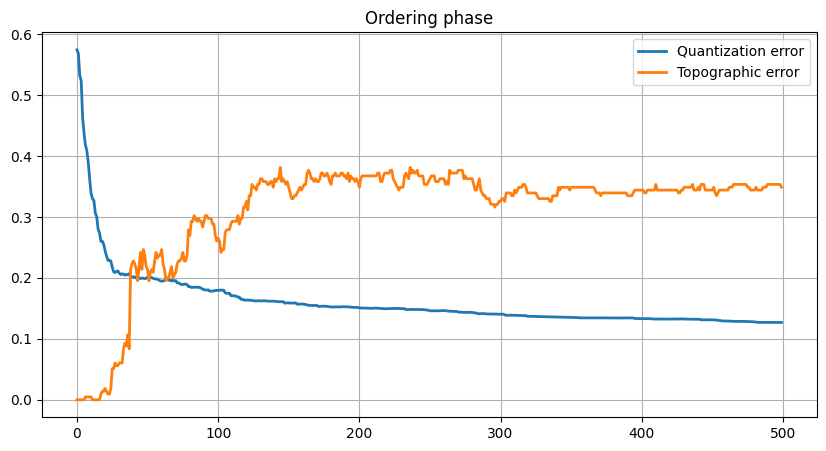

 [ 50000 / 50000 ] 100% - 0:00:00 left 
 quantization error: 0.11219337783486086


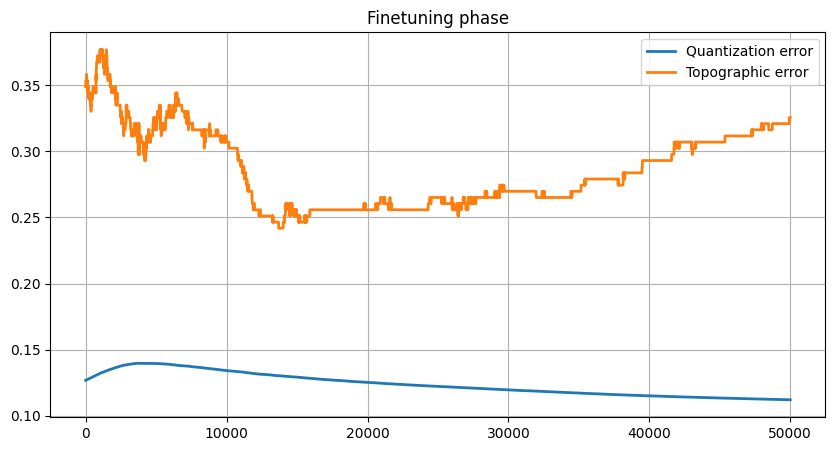

In [132]:
#decay function 

def decay_fcn(lr,actual_t,max_t):
    '''
    Função para decaimento da taxa de aprendizado. 
    
    ## INPUTS:
    lr - Taxa de aprendizado inicial
    actual_t - Tempo atual da iteração
    max_t - Tempo máximo da iteração

    ## OUTPUT:
    - taxa de aprendizado atualizada.
    '''

    new_lr = lr/(1 + 2*actual_t/max_t)

    return new_lr


m = int(np.sqrt(5*np.sqrt(values.shape[0]))) #Dimensão X do mapa de Kohonen
n = m #Dimensão Y do mapa de Kohonen
print("Dimensões do mapa de Kohonen: ", m, "x", n, ": ", m*n, "neurônios")
lr_ordering = 0.1 #Taxa de aprendizado - Ordering phase #! Alto > 0.02
lr_finetuning = 0.001 #Taxa de aprendizado - Finetuning phase #! Slide < 0.02

topology = "hexagonal" #! A hexagonal é melhor pois permite um número maior de vizinhos, tornando mais uniforme o aprendizado.

ordering_time = 500 #! Número menor para a fase de ordenaçao.
finetuning_time = 50000 #! formula nos Slides
decay_fun =  decay_fcn 

#Dimensão do vetor de entrada
input_len = values.shape[1]

X = minmax_scale(values)

som = MiniSom(m,n,input_len,learning_rate=lr_ordering,topology=topology,decay_function=decay_fcn)
som.pca_weights_init(values)

som.train_random(X, ordering_time, verbose=True)

fig = plt.figure(figsize=(10, 5))
plt.title('Ordering phase')
plt.plot(som._quantization_error,linewidth=2,label='Quantization error')
plt.plot(som._topographic_error,linewidth=2, label='Topographic error')
plt.legend()
plt.grid()
plt.show()

som._learning_rate = lr_finetuning #Para mudar a taxa de aprendizado durante o período de finetuning 

som.train_random(X, finetuning_time, verbose=True)

fig = plt.figure(figsize=(10, 5))
plt.title('Finetuning phase')
plt.plot(som._quantization_error,linewidth=2,label='Quantization error')
plt.plot(som._topographic_error,linewidth=2, label='Topographic error')
plt.legend()
plt.grid()
plt.show()

Foi mantida a mesma metodologia da questão anterior. Foi separado em 2 testes,cada um com 3 experimentos, onde se variava e mantinha a taxa de aprendizagem, ou número de iterações na etapa de ajuste fino.  

O primeiro experimento foi variando a taxa de aprendizagem em 0.01, 0.001 e 0.0001. A taxa de aprendizagem é responsável por fornecer aos pesos o quanto eles se atualizam em cada iteração. Podemos ver que valores altos para a taxa de aprendizagem com muitas iterações, como é de praxe nessa etapa, fez com que  o erro topológico aumentasse devido a grande atualizações nos pesos. O valor mediano por sua vez, fez ambos os erros diminuírem e depois se estabilizou em um plateau, o que mostrou ser um valor razoável para atualizar os pesos na etapa de ajuste fino. E quando a taxa foi muito pequena ambos os erros permaneceram constantes devido a baixa contribuição dela.

Variando agora o número de iterações e mantendo a taxa de aprendizagem em 0.001, vemos que para uma taxa de aprendizagem razoável conforme o número de iterações vai aumentando o erro vai diminuindo até chegar à um plateau e aumenta após ter chegado em seu mínimo, pois qualquer alteração após chegar o mínimo resulta numa piora do modelo.  

##### 6. Modifique a função de decaimento da taxa de aprendizado. Esta mudança gera algum impacto no mapa gerado? Justifique

Dimensões do mapa de Kohonen:  8 x 8 :  64 neurônios
 [ 500 / 500 ] 100% - 0:00:00 left 
 quantization error: 0.16388132952125364


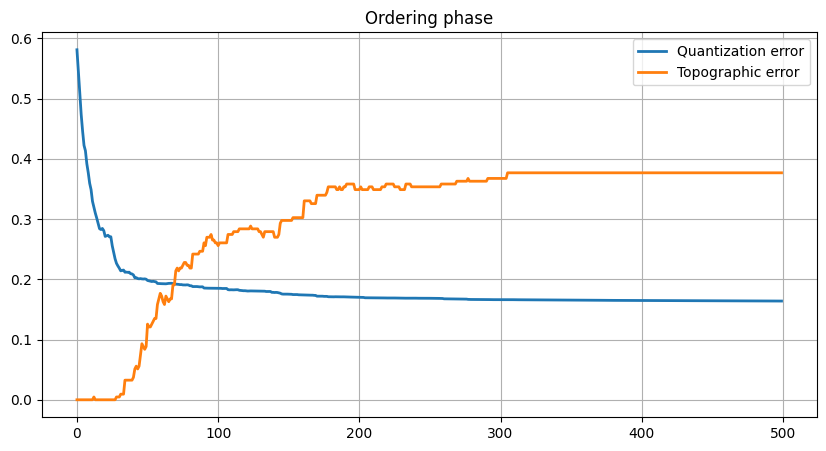

 [ 20000 / 20000 ] 100% - 0:00:00 left 
 quantization error: 0.15724740125617842


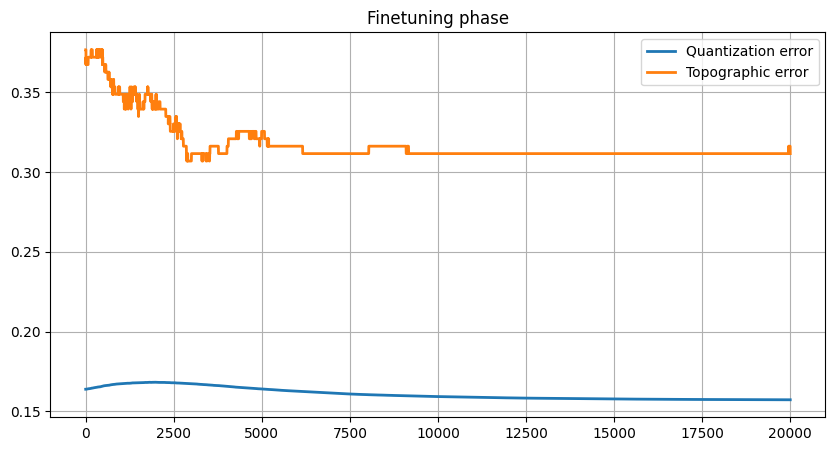

In [135]:
#decay function 

def decay_fcn(lr,actual_t,max_t):
    '''
    Função para decaimento da taxa de aprendizado. 
    
    ## INPUTS:
    lr - Taxa de aprendizado inicial
    actual_t - Tempo atual da iteração
    max_t - Tempo máximo da iteração

    ## OUTPUT:
    - taxa de aprendizado atualizada.
    '''

    new_lr = lr/(1 + 2*actual_t/max_t)

    return new_lr

def exp_decay(lr, actual_t, max_t):
    """Decaimento exponencial"""
    return lr * np.exp(-actual_t / (max_t/4))

m = int(np.sqrt(5*np.sqrt(values.shape[0]))) #Dimensão X do mapa de Kohonen
n = m #Dimensão Y do mapa de Kohonen
print("Dimensões do mapa de Kohonen: ", m, "x", n, ": ", m*n, "neurônios")
lr_ordering = 0.1 #Taxa de aprendizado - Ordering phase #! Alto > 0.02
lr_finetuning = 0.001 #Taxa de aprendizado - Finetuning phase #! Slide < 0.02

topology = "hexagonal" #! A hexagonal é melhor pois permite um número maior de vizinhos, tornando mais uniforme o aprendizado.

ordering_time = 500 #! Número menor para a fase de ordenaçao.
finetuning_time = 20000 #! formula nos Slides
# decay_fun =  decay_fcn
decay_fun =  exp_decay

#Dimensão do vetor de entrada
input_len = values.shape[1]

X = minmax_scale(values)

som = MiniSom(m,n,input_len,learning_rate=lr_ordering,topology=topology,decay_function=decay_fun)
som.pca_weights_init(values)

som.train_random(X, ordering_time, verbose=True)

fig = plt.figure(figsize=(10, 5))
plt.title('Ordering phase')
plt.plot(som._quantization_error,linewidth=2,label='Quantization error')
plt.plot(som._topographic_error,linewidth=2, label='Topographic error')
plt.legend()
plt.grid()
plt.show()

som._learning_rate = lr_finetuning #Para mudar a taxa de aprendizado durante o período de finetuning 

som.train_random(X, finetuning_time, verbose=True)

fig = plt.figure(figsize=(10, 5))
plt.title('Finetuning phase')
plt.plot(som._quantization_error,linewidth=2,label='Quantization error')
plt.plot(som._topographic_error,linewidth=2, label='Topographic error')
plt.legend()
plt.grid()
plt.show()

Dimensões do mapa de Kohonen:  8 x 8 :  64 neurônios
 [ 500 / 500 ] 100% - 0:00:00 left 
 quantization error: 0.1028662859869027


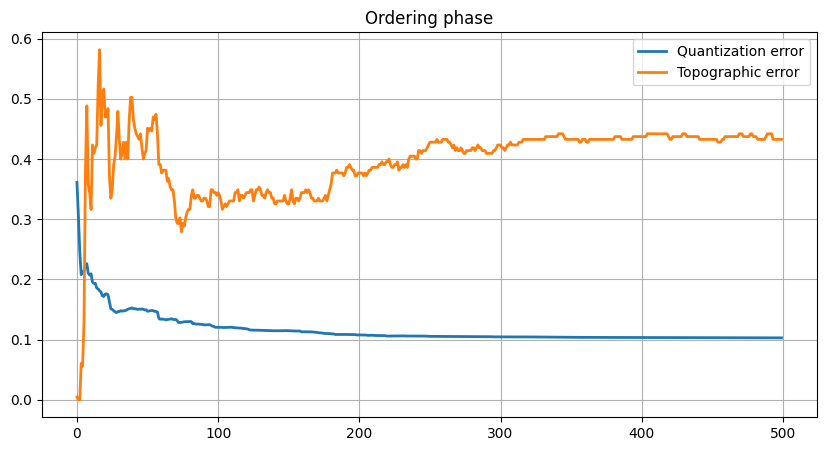

 [ 20000 / 20000 ] 100% - 0:00:00 left 
 quantization error: 0.09342089661996524


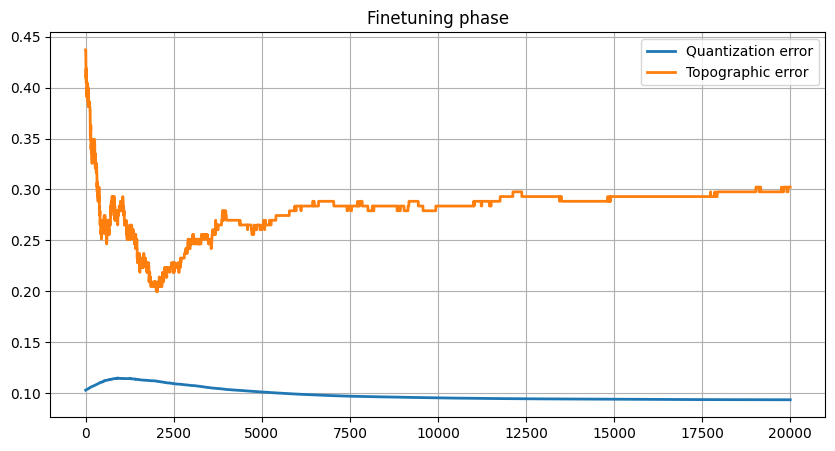

In [136]:
#decay function 

def decay_fcn(lr,actual_t,max_t):
    '''
    Função para decaimento da taxa de aprendizado. 
    
    ## INPUTS:
    lr - Taxa de aprendizado inicial
    actual_t - Tempo atual da iteração
    max_t - Tempo máximo da iteração

    ## OUTPUT:
    - taxa de aprendizado atualizada.
    '''

    new_lr = lr/(1 + 2*actual_t/max_t)

    return new_lr

def exp_decay(lr, actual_t, max_t):
    """Decaimento exponencial"""
    return lr * np.exp(-actual_t / (max_t/4))

m = int(np.sqrt(5*np.sqrt(values.shape[0]))) #Dimensão X do mapa de Kohonen
n = m #Dimensão Y do mapa de Kohonen
print("Dimensões do mapa de Kohonen: ", m, "x", n, ": ", m*n, "neurônios")
lr_ordering = 0.5 #Taxa de aprendizado - Ordering phase #! Alto > 0.02
lr_finetuning = 0.01 #Taxa de aprendizado - Finetuning phase #! Slide < 0.02

topology = "hexagonal" #! A hexagonal é melhor pois permite um número maior de vizinhos, tornando mais uniforme o aprendizado.

ordering_time = 500 #! Número menor para a fase de ordenaçao.
finetuning_time = 20000 #! formula nos Slides
# decay_fun =  decay_fcn
decay_fun =  exp_decay

#Dimensão do vetor de entrada
input_len = values.shape[1]

X = minmax_scale(values)

som = MiniSom(m,n,input_len,learning_rate=lr_ordering,topology=topology,decay_function=decay_fun)
som.pca_weights_init(values)

som.train_random(X, ordering_time, verbose=True)

fig = plt.figure(figsize=(10, 5))
plt.title('Ordering phase')
plt.plot(som._quantization_error,linewidth=2,label='Quantization error')
plt.plot(som._topographic_error,linewidth=2, label='Topographic error')
plt.legend()
plt.grid()
plt.show()

som._learning_rate = lr_finetuning #Para mudar a taxa de aprendizado durante o período de finetuning 

som.train_random(X, finetuning_time, verbose=True)

fig = plt.figure(figsize=(10, 5))
plt.title('Finetuning phase')
plt.plot(som._quantization_error,linewidth=2,label='Quantization error')
plt.plot(som._topographic_error,linewidth=2, label='Topographic error')
plt.legend()
plt.grid()
plt.show()

Dimensões do mapa de Kohonen:  8 x 8 :  64 neurônios
 [  22 / 250 ]   9% - 0:00:02 left 

 [ 250 / 250 ] 100% - 0:00:00 left 
 quantization error: 0.12235888598336052


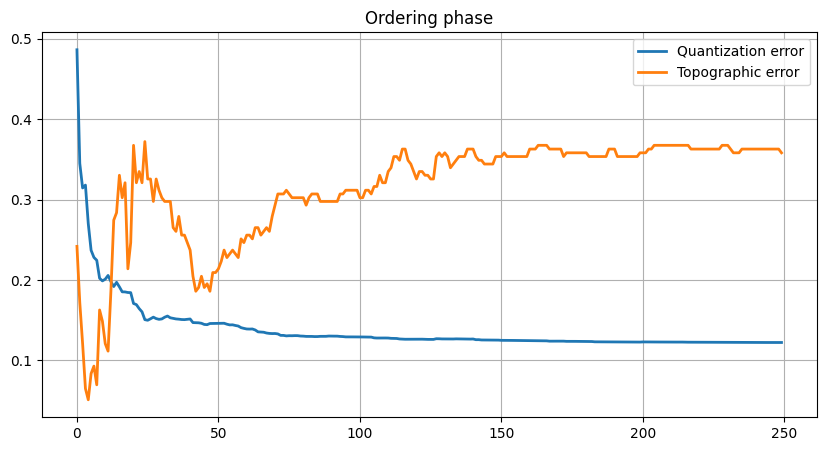

 [ 3000 / 3000 ] 100% - 0:00:00 left 
 quantization error: 0.12190459482225081


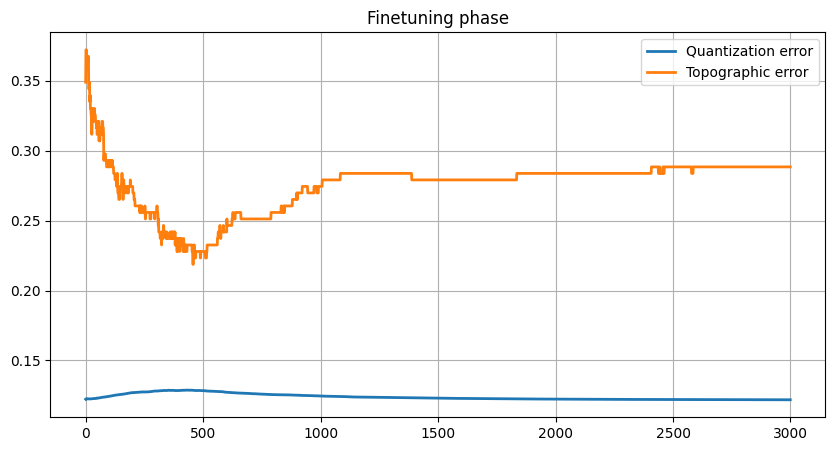

In [142]:
#decay function 

def decay_fcn(lr,actual_t,max_t):
    '''
    Função para decaimento da taxa de aprendizado. 
    
    ## INPUTS:
    lr - Taxa de aprendizado inicial
    actual_t - Tempo atual da iteração
    max_t - Tempo máximo da iteração

    ## OUTPUT:
    - taxa de aprendizado atualizada.
    '''

    new_lr = lr/(1 + 2*actual_t/max_t)

    return new_lr

def exp_decay(lr, actual_t, max_t):
    """Decaimento exponencial"""
    return lr * np.exp(-actual_t / (max_t/4))

m = int(np.sqrt(5*np.sqrt(values.shape[0]))) #Dimensão X do mapa de Kohonen
n = m #Dimensão Y do mapa de Kohonen
print("Dimensões do mapa de Kohonen: ", m, "x", n, ": ", m*n, "neurônios")
lr_ordering = 0.5 #Taxa de aprendizado - Ordering phase #! Alto > 0.02
lr_finetuning = 0.01 #Taxa de aprendizado - Finetuning phase #! Slide < 0.02

topology = "hexagonal" #! A hexagonal é melhor pois permite um número maior de vizinhos, tornando mais uniforme o aprendizado.

ordering_time = 250 #! Número menor para a fase de ordenaçao.
finetuning_time = 3000 #! formula nos Slides
# decay_fun =  decay_fcn
decay_fun =  exp_decay

#Dimensão do vetor de entrada
input_len = values.shape[1]

X = minmax_scale(values)

som = MiniSom(m,n,input_len,learning_rate=lr_ordering,topology=topology,decay_function=decay_fun)
som.pca_weights_init(values)

som.train_random(X, ordering_time, verbose=True)

fig = plt.figure(figsize=(10, 5))
plt.title('Ordering phase')
plt.plot(som._quantization_error,linewidth=2,label='Quantization error')
plt.plot(som._topographic_error,linewidth=2, label='Topographic error')
plt.legend()
plt.grid()
plt.show()

som._learning_rate = lr_finetuning #Para mudar a taxa de aprendizado durante o período de finetuning 

som.train_random(X, finetuning_time, verbose=True)

fig = plt.figure(figsize=(10, 5))
plt.title('Finetuning phase')
plt.plot(som._quantization_error,linewidth=2,label='Quantization error')
plt.plot(som._topographic_error,linewidth=2, label='Topographic error')
plt.legend()
plt.grid()
plt.show()

Dimensões do mapa de Kohonen:  8 x 8 :  64 neurônios
 [ 300 / 300 ] 100% - 0:00:00 left 
 quantization error: 0.1407719461960413


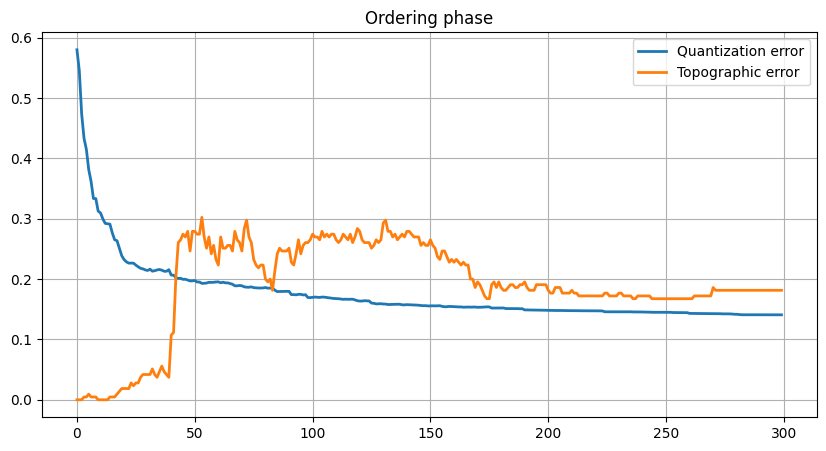

 [ 10000 / 10000 ] 100% - 0:00:00 left 
 quantization error: 0.13702400187139327


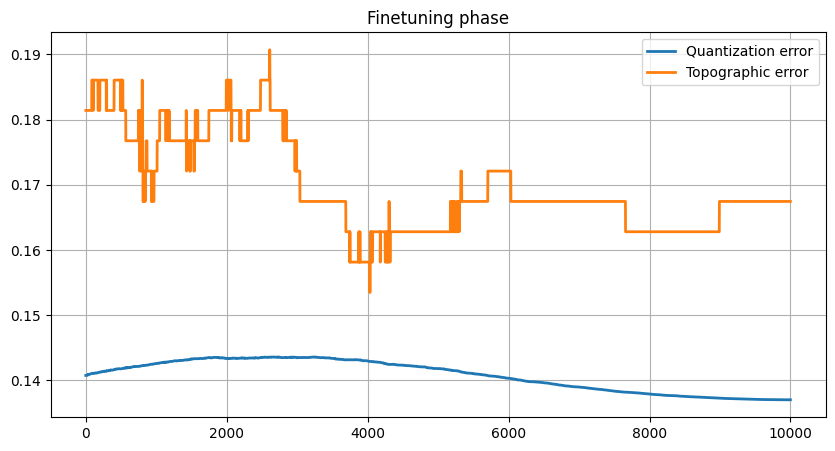

In [143]:
#decay function 

def decay_fcn(lr,actual_t,max_t):
    '''
    Função para decaimento da taxa de aprendizado. 
    
    ## INPUTS:
    lr - Taxa de aprendizado inicial
    actual_t - Tempo atual da iteração
    max_t - Tempo máximo da iteração

    ## OUTPUT:
    - taxa de aprendizado atualizada.
    '''

    new_lr = lr/(1 + 2*actual_t/max_t)

    return new_lr

def quad_decay(lr, actual_t, max_t):
    """Decaimento quadrático"""
    return lr * (1 - (actual_t/max_t)**2)

def exp_decay(lr, actual_t, max_t):
    """Decaimento exponencial"""
    return lr * np.exp(-actual_t / (max_t/4))

m = int(np.sqrt(5*np.sqrt(values.shape[0]))) #Dimensão X do mapa de Kohonen
n = m #Dimensão Y do mapa de Kohonen
print("Dimensões do mapa de Kohonen: ", m, "x", n, ": ", m*n, "neurônios")
lr_ordering = 0.1 #Taxa de aprendizado - Ordering phase #! Alto > 0.02
lr_finetuning = 0.001 #Taxa de aprendizado - Finetuning phase #! Slide < 0.02

topology = "hexagonal" #! A hexagonal é melhor pois permite um número maior de vizinhos, tornando mais uniforme o aprendizado.

ordering_time = 300 #! Número menor para a fase de ordenaçao.
finetuning_time = 10000 #! formula nos Slides
# decay_fun =  decay_fcn
decay_fun =  quad_decay

#Dimensão do vetor de entrada
input_len = values.shape[1]

X = minmax_scale(values)

som = MiniSom(m,n,input_len,learning_rate=lr_ordering,topology=topology,decay_function=decay_fun)
som.pca_weights_init(values)

som.train_random(X, ordering_time, verbose=True)

fig = plt.figure(figsize=(10, 5))
plt.title('Ordering phase')
plt.plot(som._quantization_error,linewidth=2,label='Quantization error')
plt.plot(som._topographic_error,linewidth=2, label='Topographic error')
plt.legend()
plt.grid()
plt.show()

som._learning_rate = lr_finetuning #Para mudar a taxa de aprendizado durante o período de finetuning 

som.train_random(X, finetuning_time, verbose=True)

fig = plt.figure(figsize=(10, 5))
plt.title('Finetuning phase')
plt.plot(som._quantization_error,linewidth=2,label='Quantization error')
plt.plot(som._topographic_error,linewidth=2, label='Topographic error')
plt.legend()
plt.grid()
plt.show()

Podemos ver que variando a função de decaimento é possível obter resultados bons. Foram feitos dois experimentos, um com uma função de decaimento exponencial e outro com uma função de decaimento quadrática, que pode ser entendida como um meio termo entre exponencial e a linear que estávamos usando anteriormente.  

O experimento com a função exponencial exerce uma forte influência sobre a taxa de aprendizagem. Por isso, tivemos que fazer alguns ajustes no hiperparâmetros aumentando a taxa inicial de aprendizagem e diminuindo o número de iterações já que os decaimentos ocorrem de maneira mais abrupta. Com esses ajustes obtemos resultados competitivos com os experimentos anteriores utilizando um decaimento linear.

O segundo experimento utilizou o decaimento quadrático. Esse decaimento, não exigiu aumento da taxa de aprendizagem. Entretanto, utilizei um número de iterações menor tanto para etapa de ordenação quanto de ajuste fino. Com isso, conseguiu-se resultados melhores que as questões anteriores, com erros de quantização abaixo de 0.15 e topográfico abaixo de 0.2.

##### 7. Altere a função de vizinhança. Avalie o resultado.

Dimensões do mapa de Kohonen:  8 x 8 :  64 neurônios
 [ 300 / 300 ] 100% - 0:00:00 left 
 quantization error: 0.23137116084773032


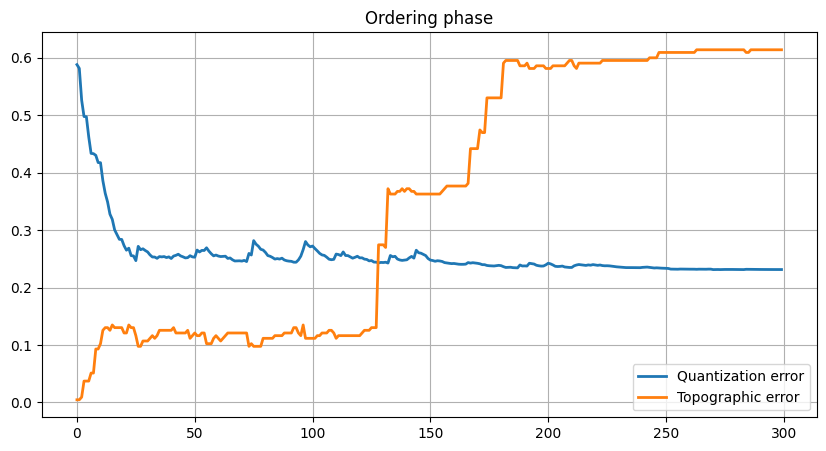

 [ 10000 / 10000 ] 100% - 0:00:00 left 
 quantization error: 0.23110162311202034


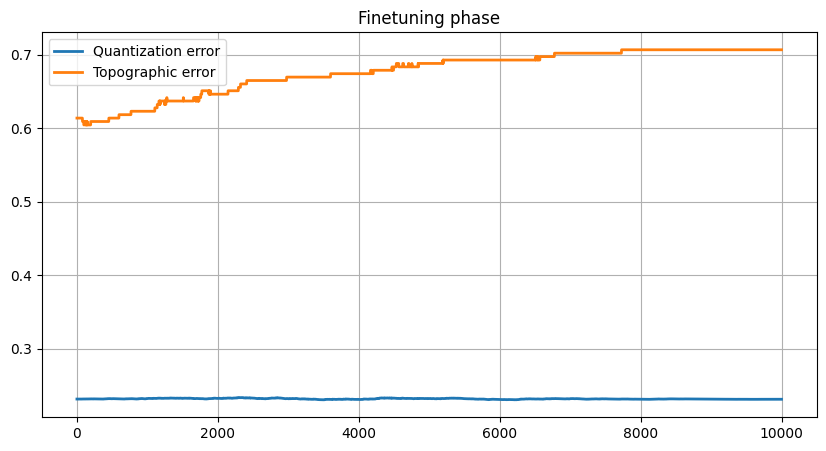

In [144]:
#decay function 

def decay_fcn(lr,actual_t,max_t):
    '''
    Função para decaimento da taxa de aprendizado. 
    
    ## INPUTS:
    lr - Taxa de aprendizado inicial
    actual_t - Tempo atual da iteração
    max_t - Tempo máximo da iteração

    ## OUTPUT:
    - taxa de aprendizado atualizada.
    '''

    new_lr = lr/(1 + 2*actual_t/max_t)

    return new_lr

def quad_decay(lr, actual_t, max_t):
    """Decaimento quadrático"""
    return lr * (1 - (actual_t/max_t)**2)

def exp_decay(lr, actual_t, max_t):
    """Decaimento exponencial"""
    return lr * np.exp(-actual_t / (max_t/4))

m = int(np.sqrt(5*np.sqrt(values.shape[0]))) #Dimensão X do mapa de Kohonen
n = m #Dimensão Y do mapa de Kohonen
print("Dimensões do mapa de Kohonen: ", m, "x", n, ": ", m*n, "neurônios")
lr_ordering = 0.1 #Taxa de aprendizado - Ordering phase #! Alto > 0.02
lr_finetuning = 0.001 #Taxa de aprendizado - Finetuning phase #! Slide < 0.02

topology = "hexagonal" #! A hexagonal é melhor pois permite um número maior de vizinhos, tornando mais uniforme o aprendizado.

ordering_time = 300 #! Número menor para a fase de ordenaçao.
finetuning_time = 10000 #! formula nos Slides
# decay_fun =  decay_fcn
decay_fun =  quad_decay

#Dimensão do vetor de entrada
input_len = values.shape[1]

X = minmax_scale(values)

som = MiniSom(m,n,input_len,learning_rate=lr_ordering,topology=topology,decay_function=decay_fun,
              neighborhood_function='bubble')
som.pca_weights_init(values)

som.train_random(X, ordering_time, verbose=True)

fig = plt.figure(figsize=(10, 5))
plt.title('Ordering phase')
plt.plot(som._quantization_error,linewidth=2,label='Quantization error')
plt.plot(som._topographic_error,linewidth=2, label='Topographic error')
plt.legend()
plt.grid()
plt.show()

som._learning_rate = lr_finetuning #Para mudar a taxa de aprendizado durante o período de finetuning 

som.train_random(X, finetuning_time, verbose=True)

fig = plt.figure(figsize=(10, 5))
plt.title('Finetuning phase')
plt.plot(som._quantization_error,linewidth=2,label='Quantization error')
plt.plot(som._topographic_error,linewidth=2, label='Topographic error')
plt.legend()
plt.grid()
plt.show()

Dimensões do mapa de Kohonen:  8 x 8 :  64 neurônios
 [ 300 / 300 ] 100% - 0:00:00 left 
 quantization error: 0.1341259148801988


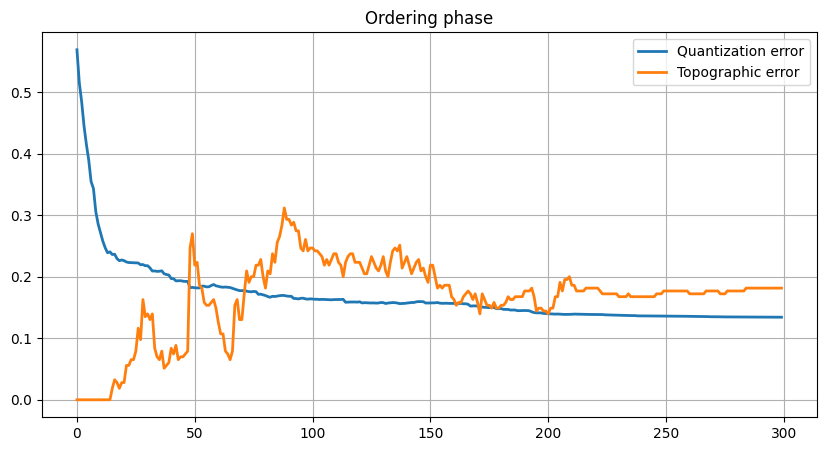

 [ 10000 / 10000 ] 100% - 0:00:00 left 
 quantization error: 0.12466344063226502


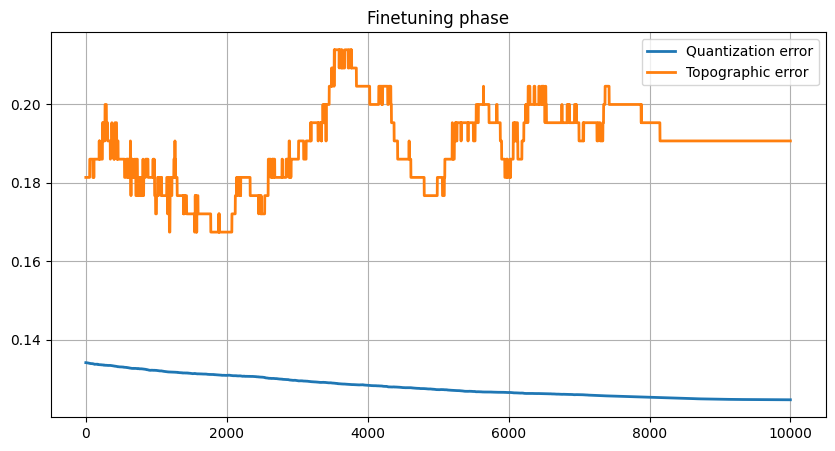

In [146]:
#decay function 

def decay_fcn(lr,actual_t,max_t):
    '''
    Função para decaimento da taxa de aprendizado. 
    
    ## INPUTS:
    lr - Taxa de aprendizado inicial
    actual_t - Tempo atual da iteração
    max_t - Tempo máximo da iteração

    ## OUTPUT:
    - taxa de aprendizado atualizada.
    '''

    new_lr = lr/(1 + 2*actual_t/max_t)

    return new_lr

def quad_decay(lr, actual_t, max_t):
    """Decaimento quadrático"""
    return lr * (1 - (actual_t/max_t)**2)

def exp_decay(lr, actual_t, max_t):
    """Decaimento exponencial"""
    return lr * np.exp(-actual_t / (max_t/4))

m = int(np.sqrt(5*np.sqrt(values.shape[0]))) #Dimensão X do mapa de Kohonen
n = m #Dimensão Y do mapa de Kohonen
print("Dimensões do mapa de Kohonen: ", m, "x", n, ": ", m*n, "neurônios")
lr_ordering = 0.1 #Taxa de aprendizado - Ordering phase #! Alto > 0.02
lr_finetuning = 0.001 #Taxa de aprendizado - Finetuning phase #! Slide < 0.02

topology = "hexagonal" #! A hexagonal é melhor pois permite um número maior de vizinhos, tornando mais uniforme o aprendizado.

ordering_time = 300 #! Número menor para a fase de ordenaçao.
finetuning_time = 10000 #! formula nos Slides
# decay_fun =  decay_fcn
decay_fun =  quad_decay

#Dimensão do vetor de entrada
input_len = values.shape[1]

X = minmax_scale(values)

som = MiniSom(m,n,input_len,learning_rate=lr_ordering,topology=topology,decay_function=decay_fun,
              neighborhood_function='bubble', sigma=2)
som.pca_weights_init(values)

som.train_random(X, ordering_time, verbose=True)

fig = plt.figure(figsize=(10, 5))
plt.title('Ordering phase')
plt.plot(som._quantization_error,linewidth=2,label='Quantization error')
plt.plot(som._topographic_error,linewidth=2, label='Topographic error')
plt.legend()
plt.grid()
plt.show()

som._learning_rate = lr_finetuning #Para mudar a taxa de aprendizado durante o período de finetuning 

som.train_random(X, finetuning_time, verbose=True)

fig = plt.figure(figsize=(10, 5))
plt.title('Finetuning phase')
plt.plot(som._quantization_error,linewidth=2,label='Quantization error')
plt.plot(som._topographic_error,linewidth=2, label='Topographic error')
plt.legend()
plt.grid()
plt.show()

Dimensões do mapa de Kohonen:  8 x 8 :  64 neurônios
 [ 300 / 300 ] 100% - 0:00:00 left 
 quantization error: 0.1252794520075404


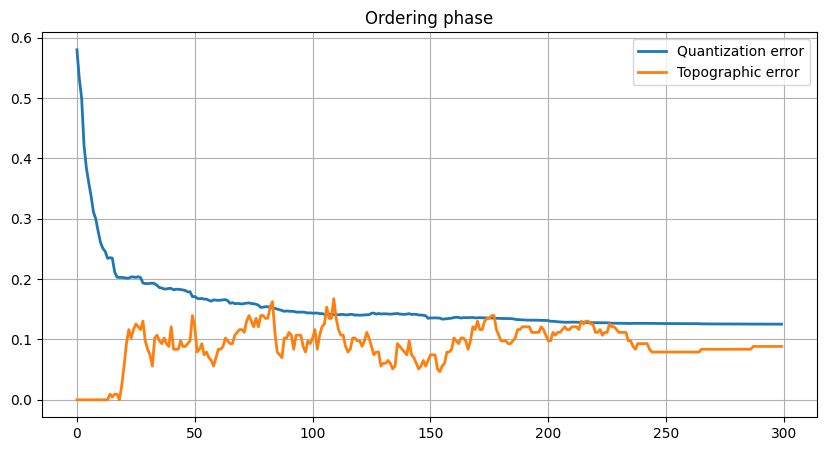

 [ 10000 / 10000 ] 100% - 0:00:00 left 
 quantization error: 0.12347582529409074


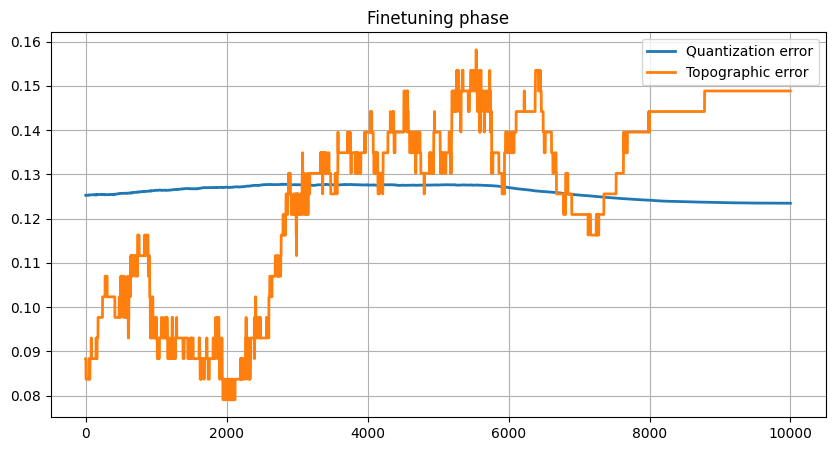

In [148]:
#decay function 

def decay_fcn(lr,actual_t,max_t):
    '''
    Função para decaimento da taxa de aprendizado. 
    
    ## INPUTS:
    lr - Taxa de aprendizado inicial
    actual_t - Tempo atual da iteração
    max_t - Tempo máximo da iteração

    ## OUTPUT:
    - taxa de aprendizado atualizada.
    '''

    new_lr = lr/(1 + 2*actual_t/max_t)

    return new_lr

def quad_decay(lr, actual_t, max_t):
    """Decaimento quadrático"""
    return lr * (1 - (actual_t/max_t)**2)

def exp_decay(lr, actual_t, max_t):
    """Decaimento exponencial"""
    return lr * np.exp(-actual_t / (max_t/4))

m = int(np.sqrt(5*np.sqrt(values.shape[0]))) #Dimensão X do mapa de Kohonen
n = m #Dimensão Y do mapa de Kohonen
print("Dimensões do mapa de Kohonen: ", m, "x", n, ": ", m*n, "neurônios")
lr_ordering = 0.1 #Taxa de aprendizado - Ordering phase #! Alto > 0.02
lr_finetuning = 0.001 #Taxa de aprendizado - Finetuning phase #! Slide < 0.02

topology = "hexagonal" #! A hexagonal é melhor pois permite um número maior de vizinhos, tornando mais uniforme o aprendizado.

ordering_time = 300 #! Número menor para a fase de ordenaçao.
finetuning_time = 10000 #! formula nos Slides
# decay_fun =  decay_fcn
decay_fun =  quad_decay

#Dimensão do vetor de entrada
input_len = values.shape[1]

X = minmax_scale(values)

som = MiniSom(m,n,input_len,learning_rate=lr_ordering,topology=topology,decay_function=decay_fun,
              neighborhood_function='bubble', sigma=3)
som.pca_weights_init(values)

som.train_random(X, ordering_time, verbose=True)

fig = plt.figure(figsize=(10, 5))
plt.title('Ordering phase')
plt.plot(som._quantization_error,linewidth=2,label='Quantization error')
plt.plot(som._topographic_error,linewidth=2, label='Topographic error')
plt.legend()
plt.grid()
plt.show()

som._learning_rate = lr_finetuning #Para mudar a taxa de aprendizado durante o período de finetuning 

som.train_random(X, finetuning_time, verbose=True)

fig = plt.figure(figsize=(10, 5))
plt.title('Finetuning phase')
plt.plot(som._quantization_error,linewidth=2,label='Quantization error')
plt.plot(som._topographic_error,linewidth=2, label='Topographic error')
plt.legend()
plt.grid()
plt.show()

Dimensões do mapa de Kohonen:  8 x 8 :  64 neurônios
 [  29 / 300 ]  10% - 0:00:01 left 

/home/thiago/Redes_Neurais/PUC_Redes_Neurais/pos_grad/lista 3/minisom/minisom.py:206: UserWarning: triangle neighborhood function does not take in account hexagonal topology
  warn('triangle neighborhood function does not ' +


 [ 300 / 300 ] 100% - 0:00:00 left 
 quantization error: 0.24581120073095863


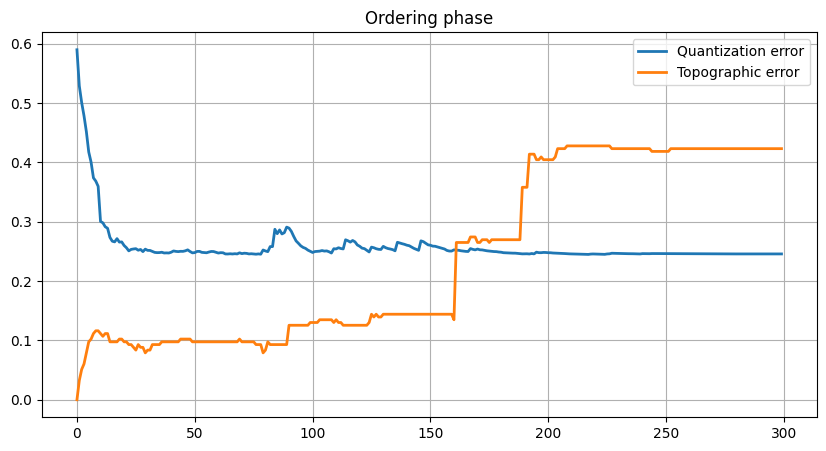

 [ 10000 / 10000 ] 100% - 0:00:00 left 
 quantization error: 0.24231740337374227


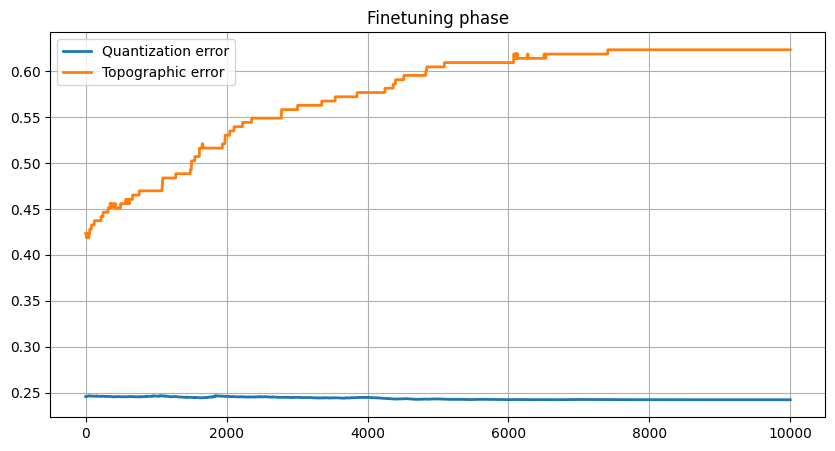

In [ ]:
#decay function 

def decay_fcn(lr,actual_t,max_t):
    '''
    Função para decaimento da taxa de aprendizado. 
    
    ## INPUTS:
    lr - Taxa de aprendizado inicial
    actual_t - Tempo atual da iteração
    max_t - Tempo máximo da iteração

    ## OUTPUT:
    - taxa de aprendizado atualizada.
    '''

    new_lr = lr/(1 + 2*actual_t/max_t)

    return new_lr

def quad_decay(lr, actual_t, max_t):
    """Decaimento quadrático"""
    return lr * (1 - (actual_t/max_t)**2)

def exp_decay(lr, actual_t, max_t):
    """Decaimento exponencial"""
    return lr * np.exp(-actual_t / (max_t/4))

m = int(np.sqrt(5*np.sqrt(values.shape[0]))) #Dimensão X do mapa de Kohonen
n = m #Dimensão Y do mapa de Kohonen
print("Dimensões do mapa de Kohonen: ", m, "x", n, ": ", m*n, "neurônios")
lr_ordering = 0.1 #Taxa de aprendizado - Ordering phase #! Alto > 0.02
lr_finetuning = 0.001 #Taxa de aprendizado - Finetuning phase #! Slide < 0.02

topology = "hexagonal" #! A hexagonal é melhor pois permite um número maior de vizinhos, tornando mais uniforme o aprendizado.

ordering_time = 300 #! Número menor para a fase de ordenaçao.
finetuning_time = 10000 #! formula nos Slides
# decay_fun =  decay_fcn
decay_fun =  quad_decay

#Dimensão do vetor de entrada
input_len = values.shape[1]

X = minmax_scale(values)

som = MiniSom(m,n,input_len,learning_rate=lr_ordering,topology=topology,decay_function=decay_fun,
              neighborhood_function='triangle', sigma=1)
som.pca_weights_init(values)

som.train_random(X, ordering_time, verbose=True)

fig = plt.figure(figsize=(10, 5))
plt.title('Ordering phase')
plt.plot(som._quantization_error,linewidth=2,label='Quantization error')
plt.plot(som._topographic_error,linewidth=2, label='Topographic error')
plt.legend()
plt.grid()
plt.show()

som._learning_rate = lr_finetuning #Para mudar a taxa de aprendizado durante o período de finetuning 

som.train_random(X, finetuning_time, verbose=True)

fig = plt.figure(figsize=(10, 5))
plt.title('Finetuning phase')
plt.plot(som._quantization_error,linewidth=2,label='Quantization error')
plt.plot(som._topographic_error,linewidth=2, label='Topographic error')
plt.legend()
plt.grid()
plt.show()

Dimensões do mapa de Kohonen:  8 x 8 :  64 neurônios
 [  30 / 300 ]  10% - 0:00:02 left 

/home/thiago/Redes_Neurais/PUC_Redes_Neurais/pos_grad/lista 3/minisom/minisom.py:206: UserWarning: triangle neighborhood function does not take in account hexagonal topology
  warn('triangle neighborhood function does not ' +


 [ 300 / 300 ] 100% - 0:00:00 left 
 quantization error: 0.11812493396960279


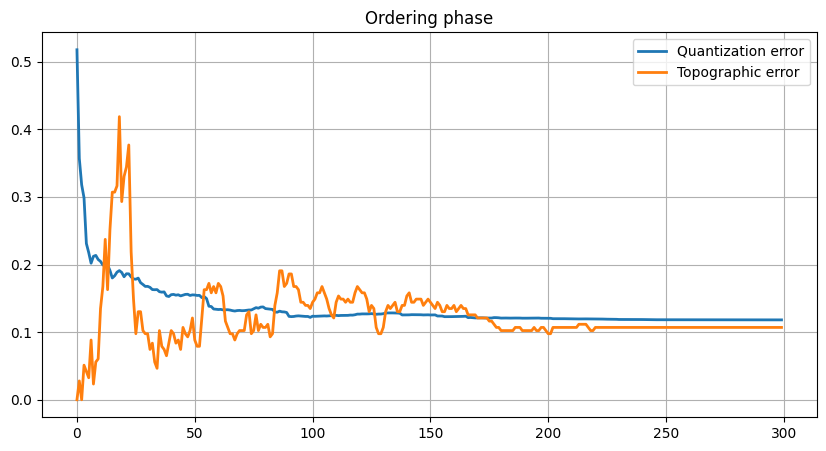

 [ 10000 / 10000 ] 100% - 0:00:00 left 
 quantization error: 0.10549502209405985


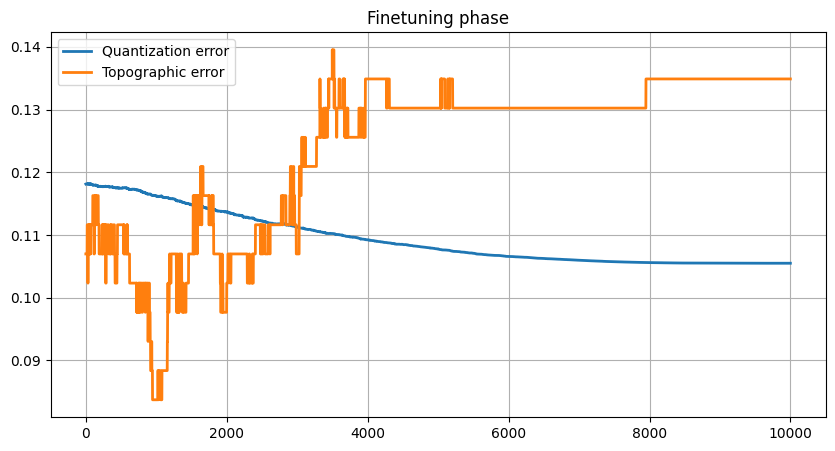

In [149]:
#decay function 

def decay_fcn(lr,actual_t,max_t):
    '''
    Função para decaimento da taxa de aprendizado. 
    
    ## INPUTS:
    lr - Taxa de aprendizado inicial
    actual_t - Tempo atual da iteração
    max_t - Tempo máximo da iteração

    ## OUTPUT:
    - taxa de aprendizado atualizada.
    '''

    new_lr = lr/(1 + 2*actual_t/max_t)

    return new_lr

def quad_decay(lr, actual_t, max_t):
    """Decaimento quadrático"""
    return lr * (1 - (actual_t/max_t)**2)

def exp_decay(lr, actual_t, max_t):
    """Decaimento exponencial"""
    return lr * np.exp(-actual_t / (max_t/4))

m = int(np.sqrt(5*np.sqrt(values.shape[0]))) #Dimensão X do mapa de Kohonen
n = m #Dimensão Y do mapa de Kohonen
print("Dimensões do mapa de Kohonen: ", m, "x", n, ": ", m*n, "neurônios")
lr_ordering = 0.1 #Taxa de aprendizado - Ordering phase #! Alto > 0.02
lr_finetuning = 0.001 #Taxa de aprendizado - Finetuning phase #! Slide < 0.02

topology = "hexagonal" #! A hexagonal é melhor pois permite um número maior de vizinhos, tornando mais uniforme o aprendizado.

ordering_time = 300 #! Número menor para a fase de ordenaçao.
finetuning_time = 10000 #! formula nos Slides
# decay_fun =  decay_fcn
decay_fun =  quad_decay

#Dimensão do vetor de entrada
input_len = values.shape[1]

X = minmax_scale(values)

som = MiniSom(m,n,input_len,learning_rate=lr_ordering,topology=topology,decay_function=decay_fun,
              neighborhood_function='triangle', sigma=2)
som.pca_weights_init(values)

som.train_random(X, ordering_time, verbose=True)

fig = plt.figure(figsize=(10, 5))
plt.title('Ordering phase')
plt.plot(som._quantization_error,linewidth=2,label='Quantization error')
plt.plot(som._topographic_error,linewidth=2, label='Topographic error')
plt.legend()
plt.grid()
plt.show()

som._learning_rate = lr_finetuning #Para mudar a taxa de aprendizado durante o período de finetuning 

som.train_random(X, finetuning_time, verbose=True)

fig = plt.figure(figsize=(10, 5))
plt.title('Finetuning phase')
plt.plot(som._quantization_error,linewidth=2,label='Quantization error')
plt.plot(som._topographic_error,linewidth=2, label='Topographic error')
plt.legend()
plt.grid()
plt.show()

Dimensões do mapa de Kohonen:  8 x 8 :  64 neurônios
 [  34 / 300 ]  11% - 0:00:01 left 

/home/thiago/Redes_Neurais/PUC_Redes_Neurais/pos_grad/lista 3/minisom/minisom.py:206: UserWarning: triangle neighborhood function does not take in account hexagonal topology
  warn('triangle neighborhood function does not ' +


 [ 300 / 300 ] 100% - 0:00:00 left 
 quantization error: 0.09532917922716566


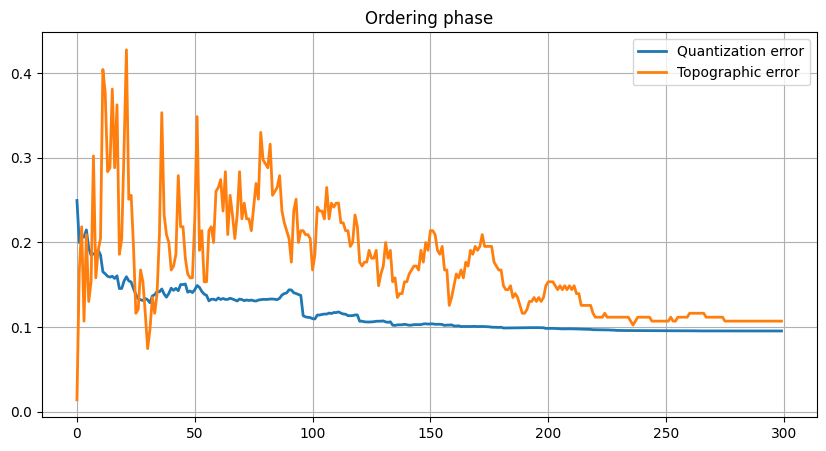

 [ 10000 / 10000 ] 100% - 0:00:00 left 
 quantization error: 0.09598321901527575


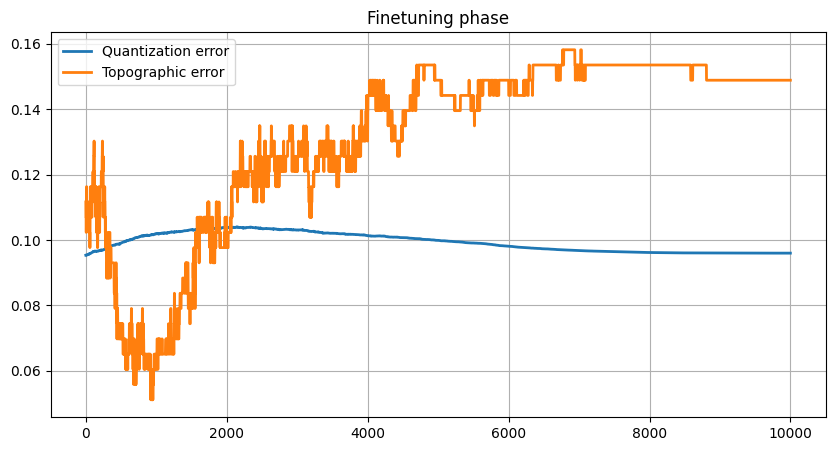

In [150]:
#decay function 

def decay_fcn(lr,actual_t,max_t):
    '''
    Função para decaimento da taxa de aprendizado. 
    
    ## INPUTS:
    lr - Taxa de aprendizado inicial
    actual_t - Tempo atual da iteração
    max_t - Tempo máximo da iteração

    ## OUTPUT:
    - taxa de aprendizado atualizada.
    '''

    new_lr = lr/(1 + 2*actual_t/max_t)

    return new_lr

def quad_decay(lr, actual_t, max_t):
    """Decaimento quadrático"""
    return lr * (1 - (actual_t/max_t)**2)

def exp_decay(lr, actual_t, max_t):
    """Decaimento exponencial"""
    return lr * np.exp(-actual_t / (max_t/4))

m = int(np.sqrt(5*np.sqrt(values.shape[0]))) #Dimensão X do mapa de Kohonen
n = m #Dimensão Y do mapa de Kohonen
print("Dimensões do mapa de Kohonen: ", m, "x", n, ": ", m*n, "neurônios")
lr_ordering = 0.1 #Taxa de aprendizado - Ordering phase #! Alto > 0.02
lr_finetuning = 0.001 #Taxa de aprendizado - Finetuning phase #! Slide < 0.02

topology = "hexagonal" #! A hexagonal é melhor pois permite um número maior de vizinhos, tornando mais uniforme o aprendizado.

ordering_time = 300 #! Número menor para a fase de ordenaçao.
finetuning_time = 10000 #! formula nos Slides
# decay_fun =  decay_fcn
decay_fun =  quad_decay

#Dimensão do vetor de entrada
input_len = values.shape[1]

X = minmax_scale(values)

som = MiniSom(m,n,input_len,learning_rate=lr_ordering,topology=topology,decay_function=decay_fun,
              neighborhood_function='triangle', sigma=3)
som.pca_weights_init(values)

som.train_random(X, ordering_time, verbose=True)

fig = plt.figure(figsize=(10, 5))
plt.title('Ordering phase')
plt.plot(som._quantization_error,linewidth=2,label='Quantization error')
plt.plot(som._topographic_error,linewidth=2, label='Topographic error')
plt.legend()
plt.grid()
plt.show()

som._learning_rate = lr_finetuning #Para mudar a taxa de aprendizado durante o período de finetuning 

som.train_random(X, finetuning_time, verbose=True)

fig = plt.figure(figsize=(10, 5))
plt.title('Finetuning phase')
plt.plot(som._quantization_error,linewidth=2,label='Quantization error')
plt.plot(som._topographic_error,linewidth=2, label='Topographic error')
plt.legend()
plt.grid()
plt.show()

Foram feitos 2 experimentos. Um com a função "bubble" e outro com a função "triangle". A primeira, é uma função que atualiza os neurônios dentro do raio com a mesma intensidade e não considera neurônios fora dele. A "triangle" por sua vez, é uma função rampa, a qual atualiza os neurônios de maneira linear em relação ao BMU e zera a contribuição fora do raio. A Gaussiana, a qual estávamos usando anteriormente, atualiza todos os neurônios dentro e fora do raio de maneira exponencial de acordo com a fórmula que leva em conta a razão entre distância do neurônio até o BMU e raio.

Sendo assim, vemos que a função "bubble" performa mal para o raio igual a 1, isso porque como ela não exerce influência em neurônios fora do raio e o raio vai diminuindo com o número de iterações, muitos dados podem ser deixados de fora aumentando assim ambos os erros. Conforme aumentamos o raio vemos que os erros diminuem expressivamente já que agora alcançam todos os dados.

Com a função "triangle" os resultados são iguais ao da função "buble" só que ainda melhores devido ao caráter linear da função de vizinhança. No começo com um raio pequeno o erro é alto e conforme aumentamos o raio o erro abaixa.

A gaussiana por sua vez, utilizada os experimentos anteriores não necessita de um raio maior visto que ela influência também os neurônios fora do raio.

## Parte 2 - Análise dos mapas

##### 1. Teste novas configurações para o modelo SOM para obter um melhor resultado. Justifique a escolha dos parâmetros do modelo selecionado.

Dimensões do mapa de Kohonen:  8 x 8 :  64 neurônios
 [ 300 / 300 ] 100% - 0:00:00 left 
 quantization error: 0.1389999141347804


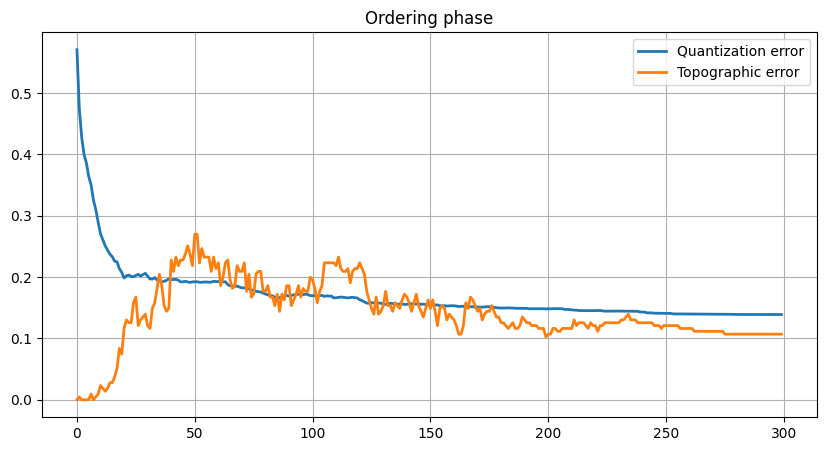

 [ 10000 / 10000 ] 100% - 0:00:00 left 
 quantization error: 0.1422701016411165


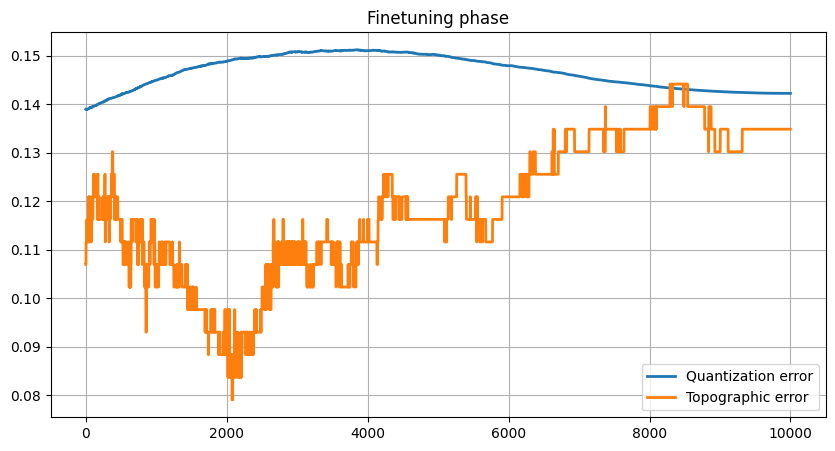

In [167]:
#decay function 

def decay_fcn(lr,actual_t,max_t):
    '''
    Função para decaimento da taxa de aprendizado. 
    
    ## INPUTS:
    lr - Taxa de aprendizado inicial
    actual_t - Tempo atual da iteração
    max_t - Tempo máximo da iteração

    ## OUTPUT:
    - taxa de aprendizado atualizada.
    '''

    new_lr = lr/(1 + 2*actual_t/max_t)

    return new_lr

def quad_decay(lr, actual_t, max_t):
    """Decaimento quadrático"""
    return lr * (1 - (actual_t/max_t)**2)

def exp_decay(lr, actual_t, max_t):
    """Decaimento exponencial"""
    return lr * np.exp(-actual_t / (max_t/4))

m = int(np.sqrt(5*np.sqrt(values.shape[0]))) #Dimensão X do mapa de Kohonen
n = m #Dimensão Y do mapa de Kohonen
print("Dimensões do mapa de Kohonen: ", m, "x", n, ": ", m*n, "neurônios")
lr_ordering = 0.1 #Taxa de aprendizado - Ordering phase #! Alto > 0.02
lr_finetuning = 0.001 #Taxa de aprendizado - Finetuning phase #! Slide < 0.02

topology = "hexagonal" #! A hexagonal é melhor pois permite um número maior de vizinhos, tornando mais uniforme o aprendizado.

ordering_time = 300 #! Número menor para a fase de ordenaçao.
finetuning_time = 10000 #! formula nos Slides
# decay_fun =  decay_fcn
decay_fun =  quad_decay

#Dimensão do vetor de entrada
input_len = values.shape[1]

X = minmax_scale(values)

som = MiniSom(m,n,input_len,learning_rate=lr_ordering,topology=topology,decay_function=decay_fun,
              neighborhood_function='gaussian', sigma=3)
som.pca_weights_init(values)

som.train_random(X, ordering_time, verbose=True)

fig = plt.figure(figsize=(10, 5))
plt.title('Ordering phase')
plt.plot(som._quantization_error,linewidth=2,label='Quantization error')
plt.plot(som._topographic_error,linewidth=2, label='Topographic error')
plt.legend()
plt.grid()
plt.show()

som._learning_rate = lr_finetuning #Para mudar a taxa de aprendizado durante o período de finetuning 

som.train_random(X, finetuning_time, verbose=True)

fig = plt.figure(figsize=(10, 5))
plt.title('Finetuning phase')
plt.plot(som._quantization_error,linewidth=2,label='Quantization error')
plt.plot(som._topographic_error,linewidth=2, label='Topographic error')
plt.legend()
plt.grid()
plt.show()

0.28867513459481287
0.28867513459481287
0.28867513459481287
0.28867513459481287
0.28867513459481287


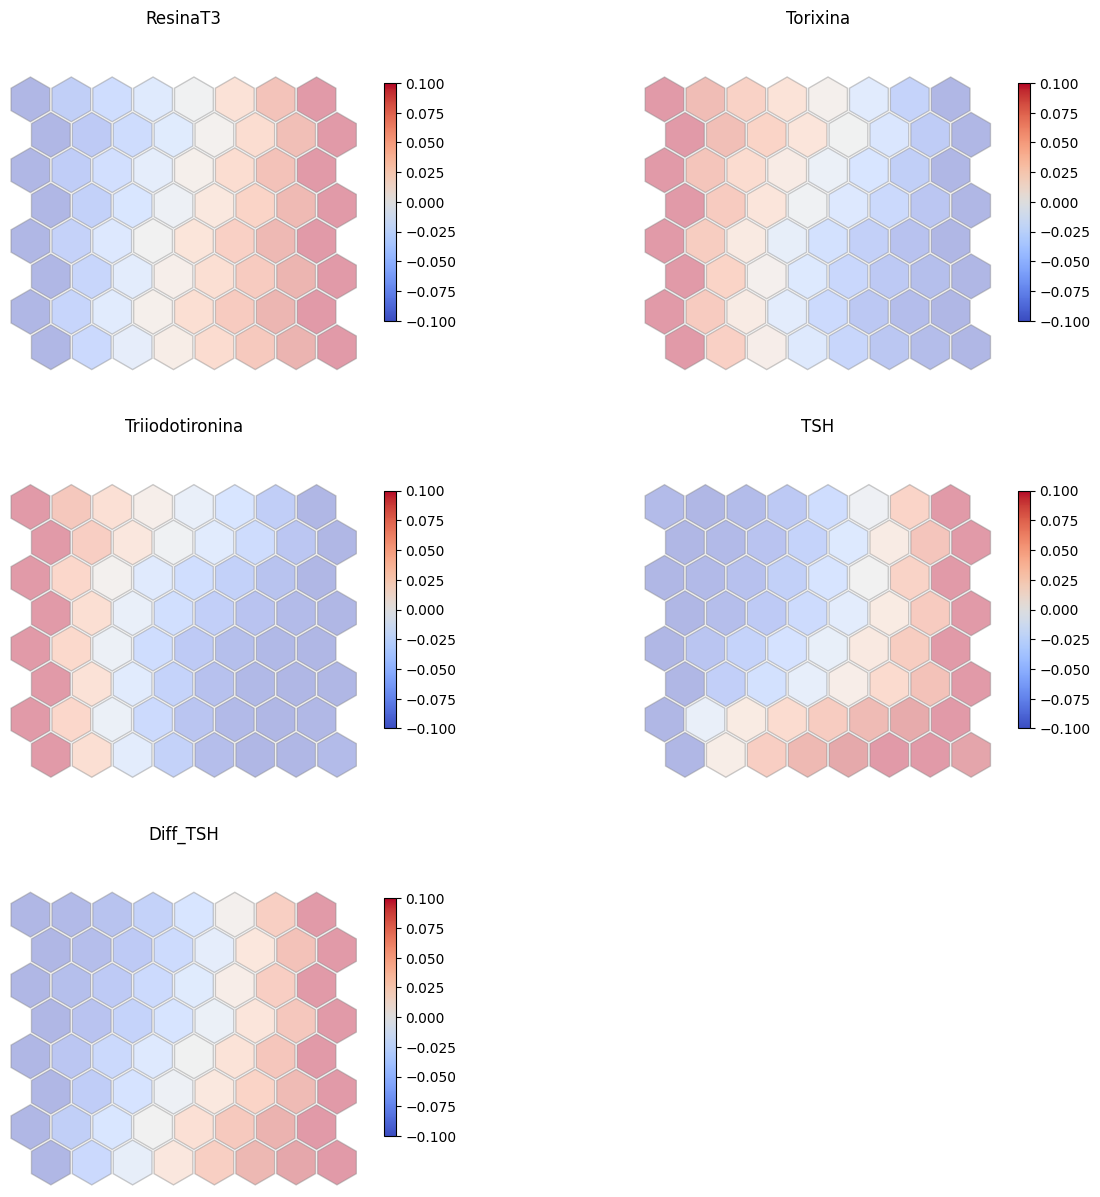

In [168]:
som.plot_map(nrows=3,ncols=2,feature_names=dataset.columns[:-1])

0.28867513459481287


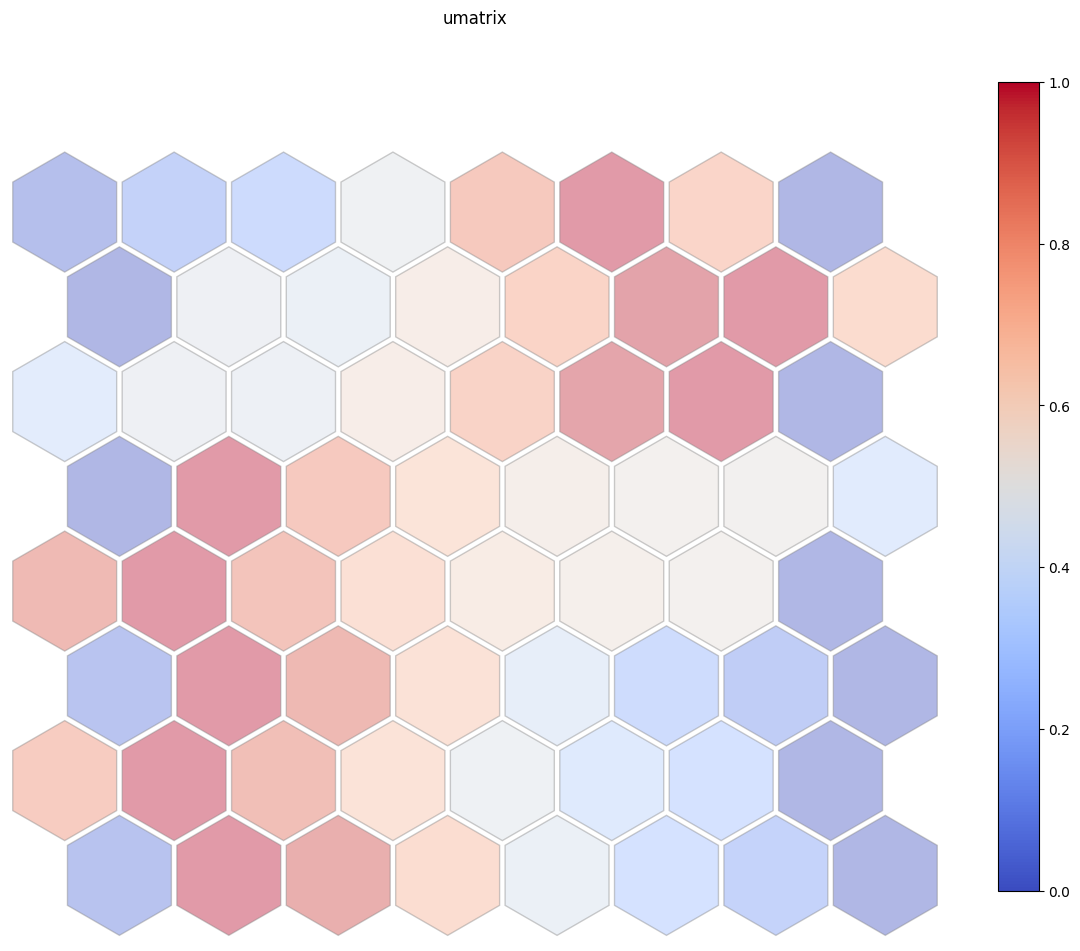

In [169]:
som.plot_umatrix()

Dimensões do mapa de Kohonen:  8 x 8 :  64 neurônios
 [  41 / 300 ]  14% - 0:00:01 left 

/home/thiago/Redes_Neurais/PUC_Redes_Neurais/pos_grad/lista 3/minisom/minisom.py:206: UserWarning: triangle neighborhood function does not take in account hexagonal topology
  warn('triangle neighborhood function does not ' +


 [ 300 / 300 ] 100% - 0:00:00 left 
 quantization error: 0.09946223861357767


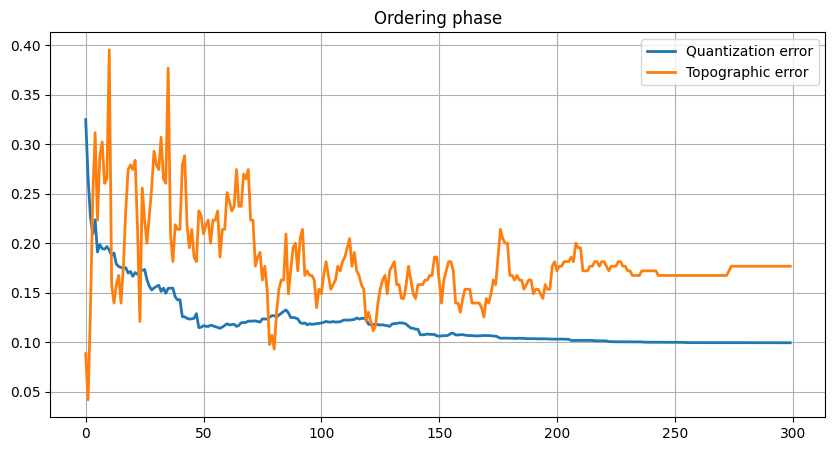

 [ 10000 / 10000 ] 100% - 0:00:00 left 
 quantization error: 0.09881657930118698


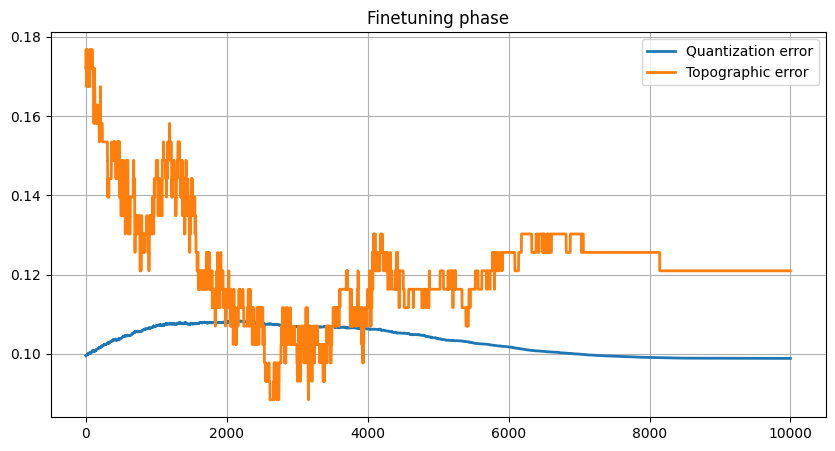

In [ ]:
#decay function 

def decay_fcn(lr,actual_t,max_t):
    '''
    Função para decaimento da taxa de aprendizado. 
    
    ## INPUTS:
    lr - Taxa de aprendizado inicial
    actual_t - Tempo atual da iteração
    max_t - Tempo máximo da iteração

    ## OUTPUT:
    - taxa de aprendizado atualizada.
    '''

    new_lr = lr/(1 + 2*actual_t/max_t)

    return new_lr

def quad_decay(lr, actual_t, max_t):
    """Decaimento quadrático"""
    return lr * (1 - (actual_t/max_t)**2)

def exp_decay(lr, actual_t, max_t):
    """Decaimento exponencial"""
    return lr * np.exp(-actual_t / (max_t/4))

m = int(np.sqrt(5*np.sqrt(values.shape[0]))) #Dimensão X do mapa de Kohonen
n = m #Dimensão Y do mapa de Kohonen
print("Dimensões do mapa de Kohonen: ", m, "x", n, ": ", m*n, "neurônios")
lr_ordering = 0.1 #Taxa de aprendizado - Ordering phase #! Alto > 0.02
lr_finetuning = 0.001 #Taxa de aprendizado - Finetuning phase #! Slide < 0.02

topology = "hexagonal" #! A hexagonal é melhor pois permite um número maior de vizinhos, tornando mais uniforme o aprendizado.

ordering_time = 300 #! Número menor para a fase de ordenaçao.
finetuning_time = 10000 #! formula nos Slides
# decay_fun =  decay_fcn
decay_fun =  quad_decay

#Dimensão do vetor de entrada
input_len = values.shape[1]

X = minmax_scale(values)

som = MiniSom(m,n,input_len,learning_rate=lr_ordering,topology=topology,decay_function=decay_fun,
              neighborhood_function='triangle', sigma=3)
som.pca_weights_init(values)

som.train_random(X, ordering_time, verbose=True)

fig = plt.figure(figsize=(10, 5))
plt.title('Ordering phase')
plt.plot(som._quantization_error,linewidth=2,label='Quantization error')
plt.plot(som._topographic_error,linewidth=2, label='Topographic error')
plt.legend()
plt.grid()
plt.show()

som._learning_rate = lr_finetuning #Para mudar a taxa de aprendizado durante o período de finetuning 

som.train_random(X, finetuning_time, verbose=True)

fig = plt.figure(figsize=(10, 5))
plt.title('Finetuning phase')
plt.plot(som._quantization_error,linewidth=2,label='Quantization error')
plt.plot(som._topographic_error,linewidth=2, label='Topographic error')
plt.legend()
plt.grid()
plt.show()

0.28867513459481287
0.28867513459481287
0.28867513459481287
0.28867513459481287
0.28867513459481287


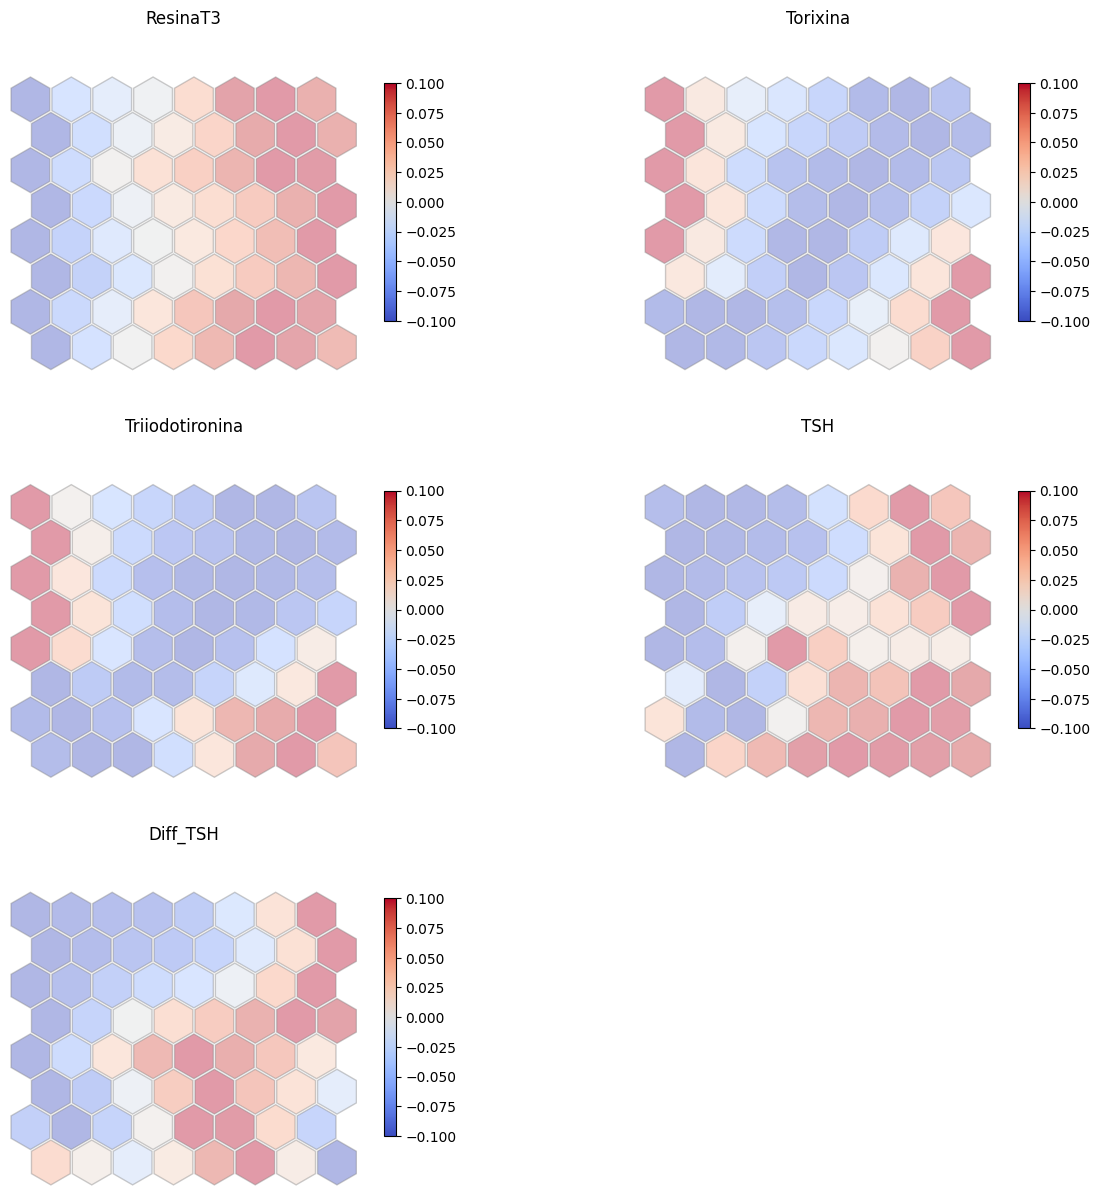

In [165]:
som.plot_map(nrows=3,ncols=2,feature_names=dataset.columns[:-1])

0.28867513459481287


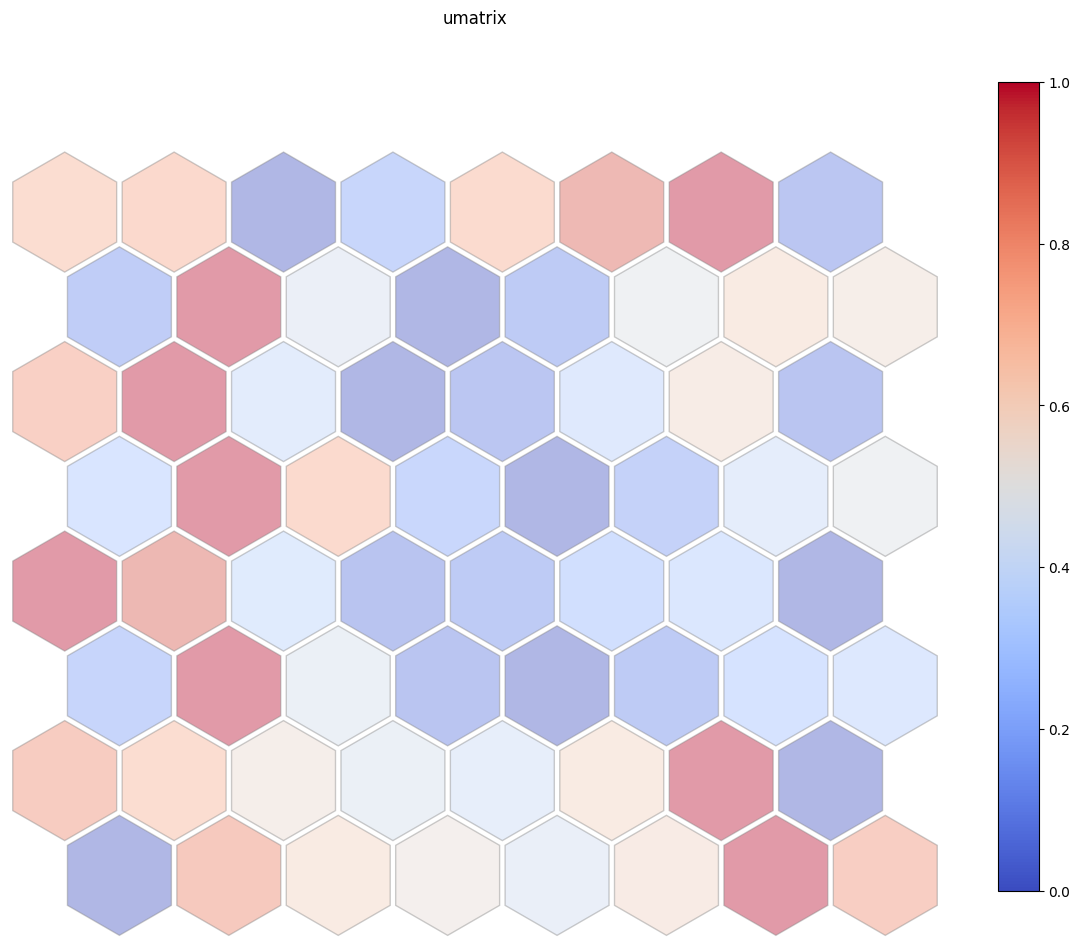

In [166]:
som.plot_umatrix()

Dimensões do mapa de Kohonen:  8 x 8 :  64 neurônios
 [ 300 / 300 ] 100% - 0:00:00 left 
 quantization error: 0.23412044770734475


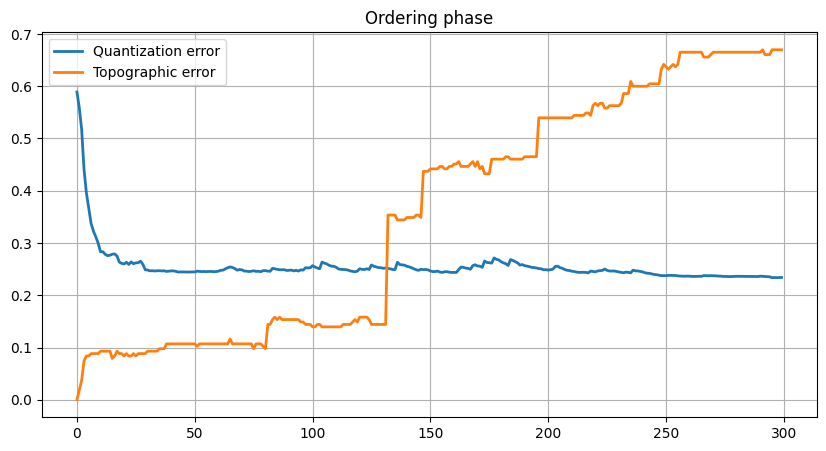

 [ 10000 / 10000 ] 100% - 0:00:00 left 
 quantization error: 0.23283687071202713


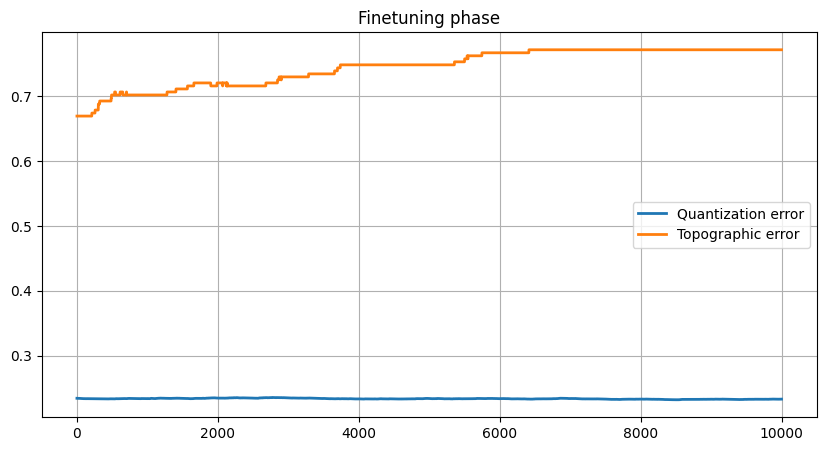

In [172]:
#decay function 

def decay_fcn(lr,actual_t,max_t):
    '''
    Função para decaimento da taxa de aprendizado. 
    
    ## INPUTS:
    lr - Taxa de aprendizado inicial
    actual_t - Tempo atual da iteração
    max_t - Tempo máximo da iteração

    ## OUTPUT:
    - taxa de aprendizado atualizada.
    '''

    new_lr = lr/(1 + 2*actual_t/max_t)

    return new_lr

def quad_decay(lr, actual_t, max_t):
    """Decaimento quadrático"""
    return lr * (1 - (actual_t/max_t)**2)

def exp_decay(lr, actual_t, max_t):
    """Decaimento exponencial"""
    return lr * np.exp(-actual_t / (max_t/4))

m = int(np.sqrt(5*np.sqrt(values.shape[0]))) #Dimensão X do mapa de Kohonen
n = m #Dimensão Y do mapa de Kohonen
print("Dimensões do mapa de Kohonen: ", m, "x", n, ": ", m*n, "neurônios")
lr_ordering = 0.1 #Taxa de aprendizado - Ordering phase #! Alto > 0.02
lr_finetuning = 0.001 #Taxa de aprendizado - Finetuning phase #! Slide < 0.02

topology = "hexagonal" #! A hexagonal é melhor pois permite um número maior de vizinhos, tornando mais uniforme o aprendizado.

ordering_time = 300 #! Número menor para a fase de ordenaçao.
finetuning_time = 10000 #! formula nos Slides
decay_fun =  decay_fcn
# decay_fun =  quad_decay

#Dimensão do vetor de entrada
input_len = values.shape[1]

X = minmax_scale(values)

som = MiniSom(m,n,input_len,learning_rate=lr_ordering,topology=topology,decay_function=decay_fun,
              neighborhood_function='bubble', sigma=1)
som.pca_weights_init(values)

som.train_random(X, ordering_time, verbose=True)

fig = plt.figure(figsize=(10, 5))
plt.title('Ordering phase')
plt.plot(som._quantization_error,linewidth=2,label='Quantization error')
plt.plot(som._topographic_error,linewidth=2, label='Topographic error')
plt.legend()
plt.grid()
plt.show()

som._learning_rate = lr_finetuning #Para mudar a taxa de aprendizado durante o período de finetuning 

som.train_random(X, finetuning_time, verbose=True)

fig = plt.figure(figsize=(10, 5))
plt.title('Finetuning phase')
plt.plot(som._quantization_error,linewidth=2,label='Quantization error')
plt.plot(som._topographic_error,linewidth=2, label='Topographic error')
plt.legend()
plt.grid()
plt.show()

0.28867513459481287
0.28867513459481287
0.28867513459481287
0.28867513459481287
0.28867513459481287


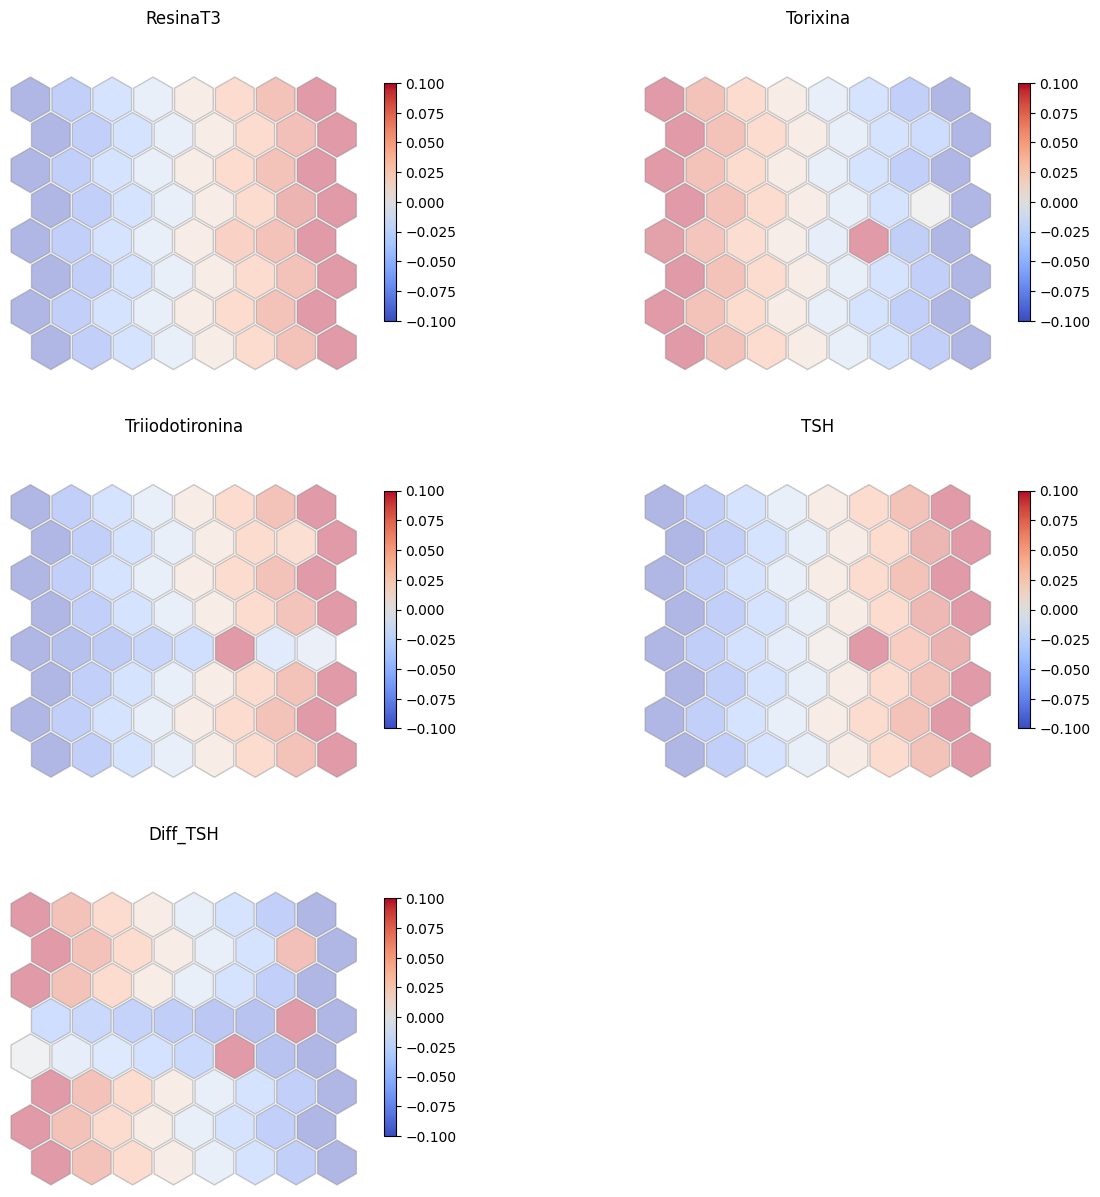

In [173]:
som.plot_map(nrows=3,ncols=2,feature_names=dataset.columns[:-1])

0.28867513459481287


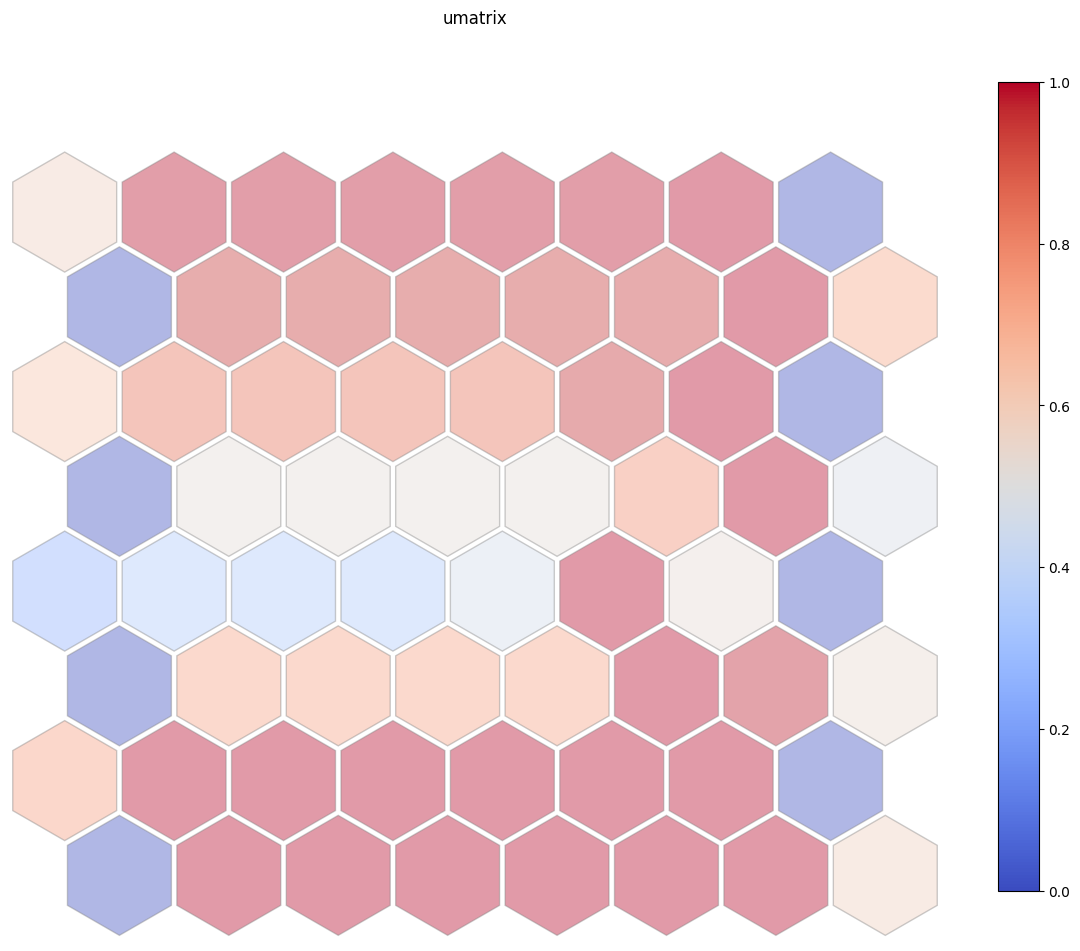

In [174]:
som.plot_umatrix()

Foram feitos 3 experimentos. 2 Tentando maximizar o modelo e um último comparativo com alguns problemas. A partir dos testes realizados nas outras questões, percebeu-se que o número de iterações ótimo estava em torno de 300, pois após isso o erro começa a crescer. Por sua vez, o número de iterações da etapa de ajuste fino apresentava bons resultados em torno de 10 mil. Essas escolhas foram feitas utilizando uma taxa de aprendizagem de 0.1 e 0.001 para as etapas de ordenação e ajuste fino, respectivamente. Esses valores foram ligeiramente altos e por isso foi utilizado uma função de decaimento da taxa do tipo quadrática para compensar esses valores. Assim, a taxa de aprendizagem tem um drecrescimento mais acentuado. Na escolha da função de vizinhança foi testada duas opções: gaussiana e triangle. O raio escolhido nesses 2 experimentos foi de tamanho 3 e apresentou melhores resultados que os de menor tamanho nas questões anteriores. A Gaussiana tem um impacto nos neurônios fora do raio enquanto a contribuição da segunda neles é zero. Além disso, a gaussiana exerce menor influência visto que a contribuição cai exponencialmente enquanto a triangle é linear. Surpreendemente, o modelo utilizando a função triangle, que é linear por partes, apresentou melhores resultados.  

O terceiro e último experimento foi escolhido uma função de ativação com contribuição constante dentro do raio, a qual tem o nome de bubble, bolha ou circular. Além disso foi escolhido um tamanho de raio pequeno de valor igual a 1. Apesar dos erros terem sido menores do que os outros experimentos ao analisarmos os mapas de ativação percebemos que o modelo não aprendeu nada. As U-Matrix dos experimentos anteriores apresentaram zonas com distância pequenas em azuis, indicando a formação de grupos de mesma semântica. Além disso, os mapas de ativação por variável indicam zonas diferentes de ativação para diferentes variáveis.

Já o terceiro experimento apresenta uma U-Matrix totalmente vermelha, indicando que os neurônios não conseguiram se agrupar. Além disso, os mapas de ativação por variável mostram que eles se ativaram no mesmo local para várias variáveis, para 3 delas totalmente a esquerda e 2 delas totalmente a direita. Isso ocorre pois, por conta da função bubble e o raio pequeno, os neurônios não conseguem aprender a topologia global dos dados se concentrando apenas nos vizinhos muito próximos, resultando em erros muito baixos mas não condizentes com a U-Matrix.

##### 2. Utilizando a melhor configuração do item anterior, analise os diferentes mapas fornecidos e caracterize os grupos de pacientes obtidos.

Dimensões do mapa de Kohonen:  8 x 8 :  64 neurônios
 [  21 / 300 ]   7% - 0:00:02 left 

/home/thiago/Redes_Neurais/PUC_Redes_Neurais/pos_grad/lista 3/minisom/minisom.py:206: UserWarning: triangle neighborhood function does not take in account hexagonal topology
  warn('triangle neighborhood function does not ' +


 [ 300 / 300 ] 100% - 0:00:00 left 
 quantization error: 0.09429203630859907


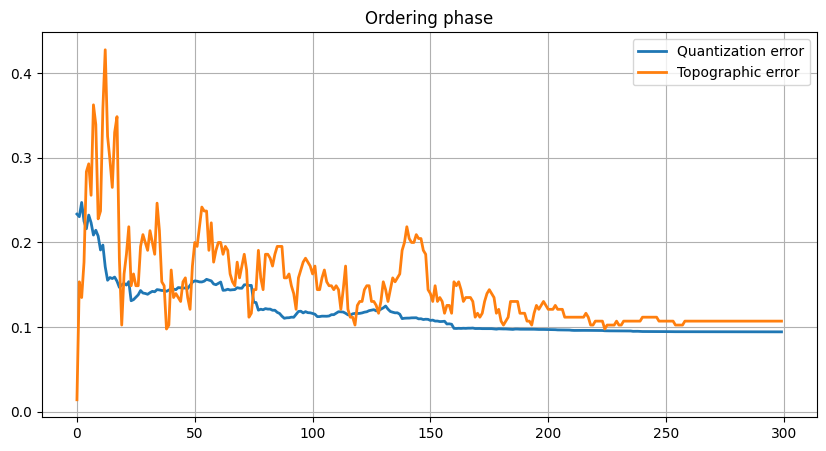

 [ 10000 / 10000 ] 100% - 0:00:00 left 
 quantization error: 0.09725566470151754


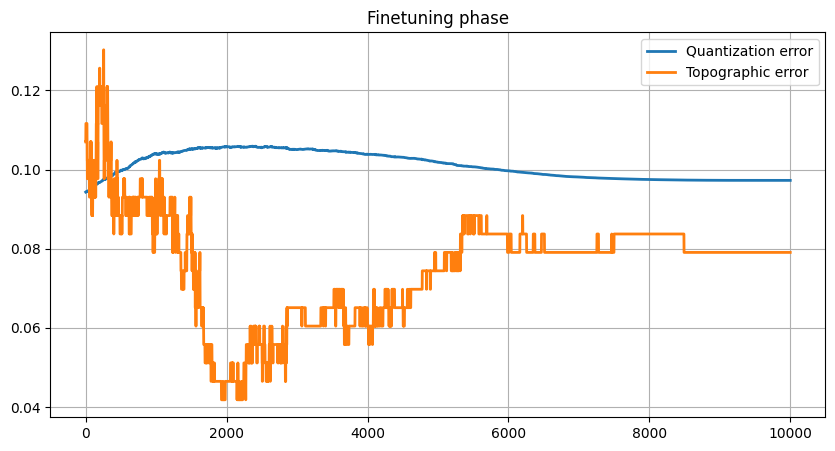

In [184]:
#decay function 

def decay_fcn(lr,actual_t,max_t):
    '''
    Função para decaimento da taxa de aprendizado. 
    
    ## INPUTS:
    lr - Taxa de aprendizado inicial
    actual_t - Tempo atual da iteração
    max_t - Tempo máximo da iteração

    ## OUTPUT:
    - taxa de aprendizado atualizada.
    '''

    new_lr = lr/(1 + 2*actual_t/max_t)

    return new_lr

def quad_decay(lr, actual_t, max_t):
    """Decaimento quadrático"""
    return lr * (1 - (actual_t/max_t)**2)

def exp_decay(lr, actual_t, max_t):
    """Decaimento exponencial"""
    return lr * np.exp(-actual_t / (max_t/4))

m = int(np.sqrt(5*np.sqrt(values.shape[0]))) #Dimensão X do mapa de Kohonen
n = m #Dimensão Y do mapa de Kohonen
print("Dimensões do mapa de Kohonen: ", m, "x", n, ": ", m*n, "neurônios")
lr_ordering = 0.1 #Taxa de aprendizado - Ordering phase #! Alto > 0.02
lr_finetuning = 0.001 #Taxa de aprendizado - Finetuning phase #! Slide < 0.02

topology = "hexagonal" #! A hexagonal é melhor pois permite um número maior de vizinhos, tornando mais uniforme o aprendizado.

ordering_time = 300 #! Número menor para a fase de ordenaçao.
finetuning_time = 10000 #! formula nos Slides
# decay_fun =  decay_fcn
decay_fun =  quad_decay

#Dimensão do vetor de entrada
input_len = values.shape[1]

X = minmax_scale(values)

som = MiniSom(m,n,input_len,learning_rate=lr_ordering,topology=topology,decay_function=decay_fun,
              neighborhood_function='triangle', sigma=3)
som.pca_weights_init(values)

som.train_random(X, ordering_time, verbose=True)

fig = plt.figure(figsize=(10, 5))
plt.title('Ordering phase')
plt.plot(som._quantization_error,linewidth=2,label='Quantization error')
plt.plot(som._topographic_error,linewidth=2, label='Topographic error')
plt.legend()
plt.grid()
plt.show()

som._learning_rate = lr_finetuning #Para mudar a taxa de aprendizado durante o período de finetuning 

som.train_random(X, finetuning_time, verbose=True)

fig = plt.figure(figsize=(10, 5))
plt.title('Finetuning phase')
plt.plot(som._quantization_error,linewidth=2,label='Quantization error')
plt.plot(som._topographic_error,linewidth=2, label='Topographic error')
plt.legend()
plt.grid()
plt.show()

0.28867513459481287
0.28867513459481287
0.28867513459481287
0.28867513459481287
0.28867513459481287


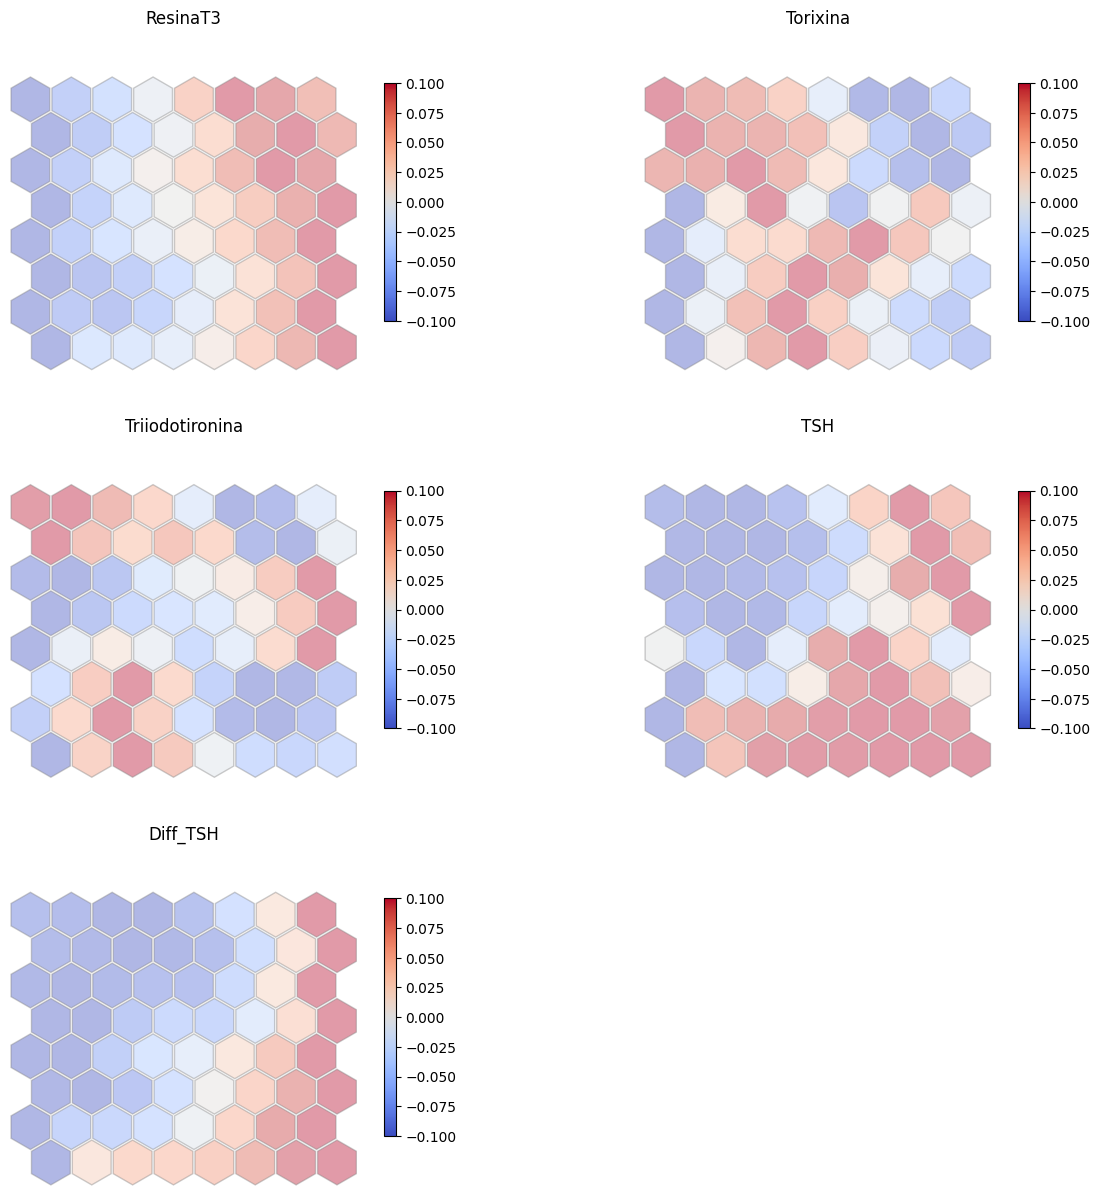

In [186]:
som.plot_map(nrows=3,ncols=2,feature_names=dataset.columns[:-1])

0.28867513459481287


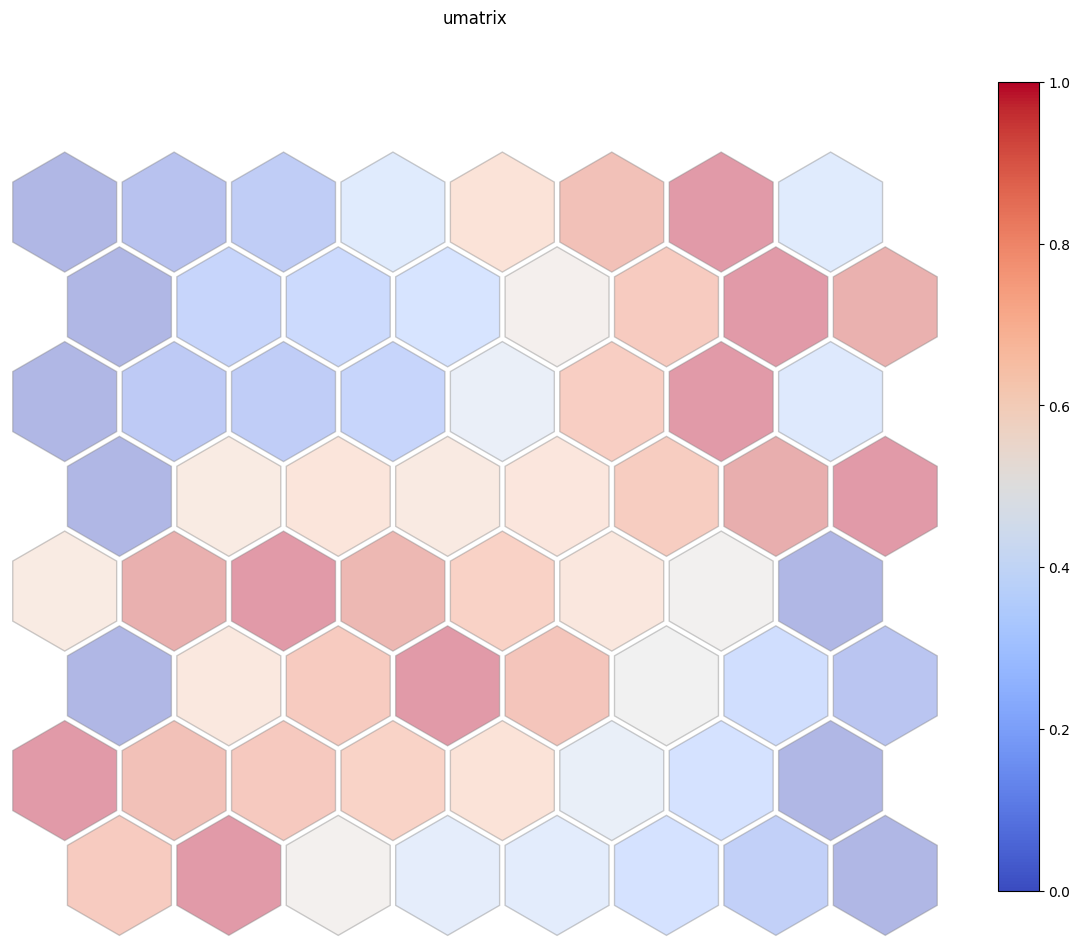

In [187]:
som.plot_umatrix()

Podemos ver que existem 2 grandes grupos, um no canto superior esquerdo e outro no canto inferior direito. Olhando para os mapas de ativação, vemos que o grupo superior esquerdo possui altas ativações nas variáveis Torixina (T4) e Triiodotironina (T3). Disturbios nesses hormônios representam pacientes com problemas na tireoide por exemplo. Já o grupo inferior direito, apresenta altas ativações nas variáveis TSH, ResinaT3 e Diff TSH. Um TSH alto pode indicar que a hipófise está tentando estimular uma tireoide pouco ativa. Enquanto ResinaT3 e DiffTSH podem refletir alterações no transporte, ligação ou disponibilidade dos hormônios tireoidianos.